# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

**Цель** проекта:
- определить параметры, влияющие на рыночную стоимость объектов недвижимости.
- определить аномалии и признаки мошеннической деятельности для построения автоматизированной системы их отслеживания.

**Подзадачи**:
- провести предобработку данных: выявить и, по возможности, заполнить пропуски, устранить дубликаты, найти аномалии/ошибки и исправить их или  (при невозможности исправления) удалить строки с ними;
- дополнить датафрэйм новыми столбцами с характеристиками недвижимости для удобства дальнейшего анализа;
- провести анализ влияния параметров на рыночную стоимость недвижимости.

**Ограничения**:
- данные по недвижимости получены от пользователя и автоматически на основе картографичесхих характеристик (учтена близость инфраструктурных объектов – парки, водоемы, аэропорты и др.). 

**Критерии оценки проекта**:

•	Как вы описываете выявленные в данных проблемы?

•	Какие способы обработки пропусков вы применяете?

•	Как используете срезы данных?

•	Решают ли ваши графики поставленные задачи?

•	Какие методы построения графиков вы используете?

•	Выводите ли вы финальные данные в сводных таблицах?

•	Считаете ли показатели взаимосвязи в данных и как вы их объясняете?

•	Соблюдаете ли вы структуру проекта и поддерживаете ли аккуратность кода?

•	Какие выводы вы делаете?

•	Оставляете ли вы комментарии к шагам?

**Описание данных**

•	airports_nearest — расстояние до ближайшего аэропорта в метрах (м)

•	balcony — число балконов

•	ceiling_height — высота потолков (м)

•	cityCenters_nearest — расстояние до центра города (м)

•	days_exposition — сколько дней было размещено объявление (от публикации до снятия)

•	first_day_exposition — дата публикации

•	floor — этаж

•	floors_total — всего этажей в доме

•	is_apartment — апартаменты (булев тип)

•	kitchen_area — площадь кухни в квадратных метрах (м²)

•	last_price — цена на момент снятия с публикации

•	living_area — жилая площадь в квадратных метрах (м²)

•	locality_name — название населённого пункта

•	open_plan — свободная планировка (булев тип)

•	parks_around3000 — число парков в радиусе 3 км

•	parks_nearest — расстояние до ближайшего парка (м)

•	ponds_around3000 — число водоёмов в радиусе 3 км

•	ponds_nearest — расстояние до ближайшего водоёма (м)

•	rooms — число комнат

•	studio — квартира-студия (булев тип)

•	total_area — общая площадь квартиры в квадратных метрах (м²)

•	total_images — число фотографий квартиры в объявлении

### Изучение общей информации о файле

Откроем файл и поставим разделитель sep='\t' для корректной визуализации датафрэйма.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')

Изучим таблицу визуально, а также посмотрим общую информацию о датафрэйме и о представленных в нем типах данных, количесьтвенных показателях выборок. 

In [6]:
data.head(3)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.7,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

Построим гистограммы для всех числовых столбцов таблицы на одном графике.

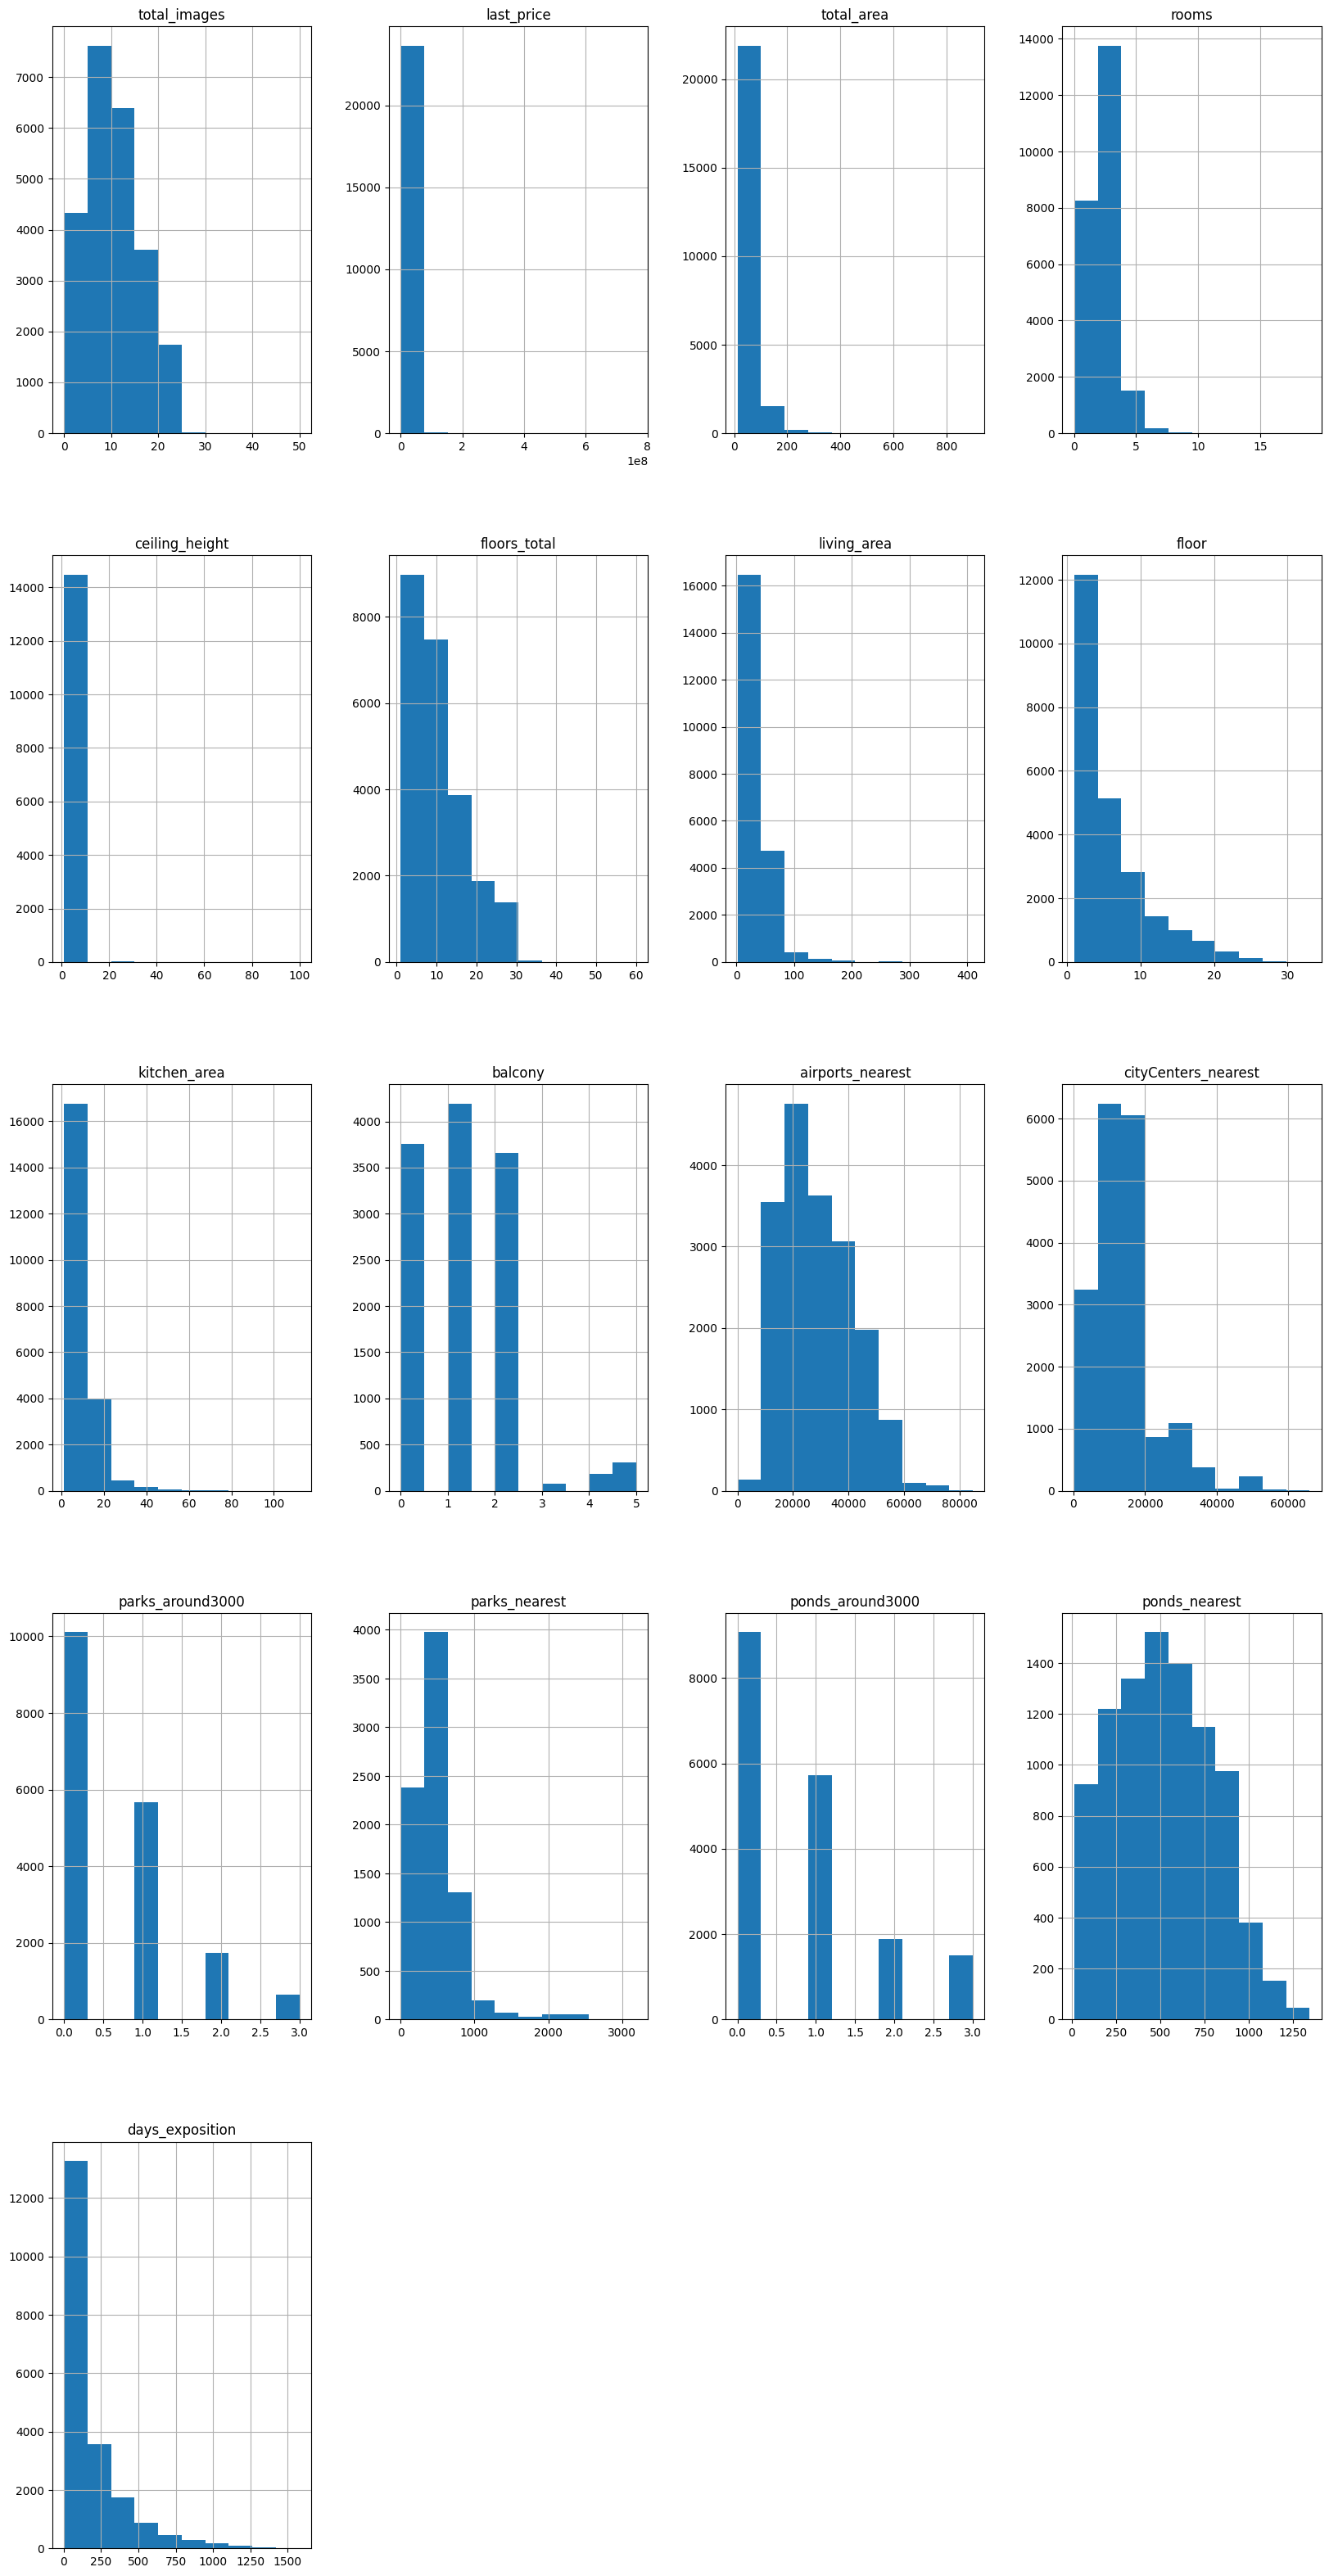

In [8]:
data.hist(figsize=(20, 40))
plt.show()

**Анализ гистограмм (в большинстве случаев):**

•	airports_nearest — расстояние до ближайшего аэропорта в метрах (м) - основная часть квартир находится в 20 км от аэропортов, меньше - в 10 км, 30, 40,... км

•	balcony — число балконов - 6-я часть квартир имеет 1 балкон, 7-я часть - 2 балкона, и совсем мало квартир - по 3, 4, 5 балконов (**вероятны ошибки - проанализируем ниже квартиры с 3, 4, 5 балконов**).

•	ceiling_height — высота потолков (м) - **не верные данные - откорректируем ниже**

•	cityCenters_nearest — расстояние до центра города (м) - бОльшая часть квартир находится в 6-20 км от центра, есть квартиры и до 5 км от центра, совсем мало - дальше 21 км.

•	days_exposition — сколько дней было размещено объявление (от публикации до снятия) - юольщая часть квартир продается за период до 120 дней (до 4 мес), меньше - до 265 дней (до 9 мес), мало - до 450 дней (до 15 мес), остальные - от 600 до 1650 д (20-55 мес = 1 г 

•	first_day_exposition — дата публикации

•	floor — этаж - большая часть квартир располагается на 1-5 этажах, это кореллирует с юОльшим количеством квартир в домах 1-5-этажках, в 2 раза меньше - 6-7 этажи, еще в 2 раза меньше 8-11 этажи, ... 11-13, 14-16, 17-20, 21-23 этажи,...

•	floors_total — всего этажей в доме - больше всего продается квартир в 1-5 этажках (обычно это старый фонд), менше - до 14 эт (средний возраст домов), еще меньше - до 30 этажей (новостройки), есть мало квартир в 30+этажках - до 40 этажей в доме (новостройки).

•	is_apartment — апартаменты (булев тип)

•	kitchen_area — площадь кухни в квадратных метрах (м²) - большая часть кухонь - до 12 (м²), сильно меньше - до 22 (м²), и совсем мало 23+ (м²)

•	last_price — цена на момент снятия с публикации - до 100 000 000 р.

•	living_area — жилая площадь в квадратных метрах (м²) - до 50 (м²), меньше - до 80 (м²), совсмем мало - 80-120 (м²) и мизер - 120+ и 160+ (м²)

•	locality_name — название населённого пункта

•	open_plan — свободная планировка (булев тип)

•	parks_around3000 — число парков в радиусе 3 км - у половины квартир парков в радиусе 3 км нет, есть 1 парк у 4й части квартир, есть 2 и 3 парка у незначительной части квартир

•	parks_nearest — расстояние до ближайшего парка (м) - у четверти квартир парки находятся на расстоянии до 600 м от них, у малой части - до 1 км, у остальных квартир парки находятся дальше 1 км. Болльшая часть данных не отмечена.

•	ponds_around3000 — число водоёмов в радиусе 3 км - у большей части квартир на расстоянии до 3 км есть водоемы: у половины - около квартиры, у четверти - до 1 км от квартиры.  

•	ponds_nearest — расстояние до ближайшего водоёма (м) - у большинства квартир рассстояние до водоема составляет 500 м и у всех - до 1,3 км. Большая части квартир располагается вблизи водоемов. Около моря большая часть располагаться не может. Совсем близкое расположение моря негативно действует на строительные материалы дома, и на технику, мебель. В остальных случаях большинство квартир находятся в хорошем расположении - у воды.

•	rooms — число комнат - больше всего 3-шек, поменьше - 1- и 2-шек, меньше всего 4+ комнатных квартир

•	studio — квартира-студия (булев тип)

•	total_area — общая площадь квартиры в квадратных метрах (м²) - до 100 (м²), меньшая часть - до 200 (м²)

•	total_images — число фотографий квартиры в объявлении - 0-25 шт.

### Предобработка данных

**Поиск пропусков**

**Задачи**:

Найти и изучить пропущенные значения в столбцах: 

o	Определить, в каких столбцах есть пропуски.

o	Заполнить пропущенные значения там, где это возможно.

o	В ячейке с типом markdown указать причины, которые могли привести к пропускам в данных.

In [9]:
# Найдем столбцы с пропусками и узнаем их количество
print(data.isna().sum())

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64


**Пропуски и их причины, устранение, изменение типа данных.**:

Столбец.         Количество пропусков, шт.
ceiling_height           9195

**Заменим пропуски на медианные значения.**

**Причина** пропуска - человек не заполнил.
________
floors_total               86
**Оставим пропуски, тк квартира может находиться на 1 этаже в 40-этажном доме, а может на 40-м. Заменить нельзя.**

**Причина** пропуска - человек не заполнил.
________
living_area              1903
**Оставим пропуски, т.к. нельзя точно предсказать жилую зону.**

**Причина** пропуска - человек не заполнил.
________
is_apartment            20924
**Заменим пропуски на значения True, а затем - на 1 (False=0) и 0 (True=0).**

**Причина** пропуска - человек не заполнил.


**Пропуски и их причины, устранение, изменение типа данных.**:


ceiling_height           9195

**Заменим пропуски на медианные значения.**

**Причина** пропуска - человек не заполнил.
________
floors_total               86
Оставим пропуски, тк квартира может находиться на 1 этаже в 40-этажном доме, а может на 40-м. Заменить нельзя.

**Причина** пропуска - человек не заполнил.
________
living_area              1903
Оставим пропуски, т.к. нельзя точно предсказать жилую зону.

**Причина** пропуска - человек не заполнил.
________
is_apartment            20924
**Заменим пропуски на значения True, а затем - на 1 (False=0) и 0 (True=0).**

**Причина** пропуска - человек не заполнил.
________
kitchen_area             2278
Оставим пропуски, т.к. нельзя точно предсказать кухонную зону.

**Причина** пропуска - человек не заполнил.
________
balcony                 11519
**Заменим пропуски на значения 0, т.к. пропуски здесь означают, что человек не указал, значит балконов нет.**

**Причина** пропуска - человек не заполнил.
________

locality_name              49
**Заменим пропуски на значения НЕТ ДАННЫХ для удобства дальнейшей работы, чтобы все переменные столбца были строкового типа.

Также найдем **дубликаты** и **устраним** их.

**Причина** пропуска - человек не заполнил.
________

airports_nearest         5542
Оставим пропуски, т.к. нельзя точно предсказать расстояния до аэропортов.

**Причина** пропуска - "компьютер" не заполнил.
________

cityCenters_nearest      5519
Оставим пропуски, т.к. нельзя точно предсказать кухонную зону.

**Причина** пропуска - "компьютер" не заполнил.
________

parks_around3000         5518
Заменять на предсказанное значение не будем, т.к. нельзя точно предсказать наличие парков в радиусе 3 км - группировкой по городу, отдалению от центра тоже нельзя предсказать, тк квартира может находиться диаметрально от квартиры с подобным расстоянием до центра.
**Заменим на 0 пропуски, если значение в столбце с расстоянием до парка 0 или 3001 м и более** Будем считать - человек не указал, значит их нет.

**Причина** пропуска - "компьютер" не заполнил.
________

parks_nearest           15620

Оставим пропуски, т.к. нельзя точно предсказать расстояния.

**Причина** пропуска - "компьютер" не заполнил.
_________
ponds_around3000         5518
Заменять на предсказанное значение не будем, т.к. нельзя точно предсказать наличие водоемов в радиусе 3 км - группировкой по городу, отдалению от водоемов тоже нельзя предсказать, тк квартира может находиться диаметрально от квартиры с подобным расстоянием до водоемов.

Оставим пропуски, т.к. нельзя точно предсказать расстояния.

**Причина** пропуска - "компьютер" не заполнил.
_________

ponds_nearest           14589
Оставим пропуски, т.к. нельзя точно предсказать расстояния.

**Причина** пропуска - "компьютер" не заполнил.
_________

days_exposition          3181

**Причина** пропуска - на текущий момент продается - еще не понятно количество дней. Текущей даты нет. Поэтому нельзя посчитать данный параментр. Но можно найти самую позднюю дату в таблице, прибавить количество дней продажи и вычесть из нее дату начала продажи квартиры с пропуском.

**Изменение типа данных**
Поменяем тип данных для удобаства дальнейшего анализа

**Заполнение пропусков. Изменение типа данных.**

In [10]:
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [11]:
# этажей в доме - удалякм строки с пропусками - их мало и этажность важна для анализа далее.
    
data['floors_total'] = data['floors_total'].dropna().astype(int)
    
data['floors_total'].isna().sum()

np.int64(86)

In [12]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

0.0

**Замена пропусков и изменение типа данных. Удаление пропусков**.

In [13]:
# Удалим пропущенные значения населенных пунктов, т.к. их мало и тк населенный пункт важен 
# для понимания рыночной стоимости недвижимости
# data['locality_name'] = data['locality_name'].dropna()
data = data.dropna(subset=['locality_name'])
data['locality_name'].isna().sum()

np.int64(0)

In [14]:
# Заполним пропуски 'is_apartment' значением True. И далее -  на единицу.
data.loc[:, 'is_apartment'] = data['is_apartment'].fillna(True)
data.loc[:, 'is_apartment'] = data['is_apartment'].astype('Int64')
data['is_apartment'].head(3)

/var/folders/nl/qb3_y6cj3lxgsxxz059t4t740000gn/T/ipykernel_77774/2837413886.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.loc[:, 'is_apartment'] = data['is_apartment'].fillna(True)


0    1
1    1
2    1
Name: is_apartment, dtype: object

In [15]:
# Заполним 0-лями пропуски балконов, тк их не указали, предположим, их нет.
data['balcony'] = data['balcony'].fillna(0).astype(int)
data['balcony'].head(3)

0    0
1    2
2    0
Name: balcony, dtype: int64

In [16]:
# Заполним нулями пропуски и поменяем тип данных
# Если не указали наличие парков рядом, предположим, что их нет рядом
data.loc[:, 'ponds_around3000'] = data['ponds_around3000'].fillna(0).astype(int)
data['ponds_around3000'].head(3)

0    2.0
1    0.0
2    2.0
Name: ponds_around3000, dtype: float64

In [17]:
# Округлим значения, пропуски оставим
data.loc[:, 'living_area'] = data['living_area'].round(2)
data['living_area'].head(3)

0    51.0
1    18.6
2    34.3
Name: living_area, dtype: float64

In [18]:
# Округлим значения, пропуски оставим
data.loc[:, 'kitchen_area'] = data['kitchen_area'].round(2)
data['kitchen_area'].head(3)

0    25.0
1    11.0
2     8.3
Name: kitchen_area, dtype: float64

In [19]:
# Округлим значения расстояний, пропуски оставим
data.loc[:, 'airports_nearest'] = data['airports_nearest'].round(2)
data['airports_nearest'].head(3)

0    18863.0
1    12817.0
2    21741.0
Name: airports_nearest, dtype: float64

In [20]:
# Округлим значения расстояний
data.loc[:, 'parks_nearest'] = data['parks_nearest'].round(2)
data['parks_nearest'].head(3)

0    482.0
1      NaN
2     90.0
Name: parks_nearest, dtype: float64

In [21]:
# Округлим значения расстояний
data.loc[:, 'cityCenters_nearest'] = data['cityCenters_nearest'].round(2)
data['cityCenters_nearest'].head(3)

0    16028.0
1    18603.0
2    13933.0
Name: cityCenters_nearest, dtype: float64

In [22]:
# Округлим значения расстояний
data.loc[:, 'living_area'] = data['living_area'].round(2)
data['living_area'].head(3)

0    51.0
1    18.6
2    34.3
Name: living_area, dtype: float64

In [23]:
# Округлим значения 
data.loc[:, 'total_area'] = data['total_area'].astype(int)
data['total_area'].head(3)

0    108.0
1     40.0
2     56.0
Name: total_area, dtype: float64

In [24]:
# Округлим значения 
data.loc[:, 'days_exposition'] = data['days_exposition'].round(2)

In [25]:
# Округлим значения 
data.loc[:, 'ponds_nearest'] = data['ponds_nearest'].round(2)

In [26]:
# Выведем data с помощью print, чтобы было видно все столбцы
print(data.head(3))

   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0  2019-03-07T00:00:00      3   
1             7   3350000.0        40.0  2018-12-04T00:00:00      1   
2            10   5196000.0        56.0  2015-08-20T00:00:00      2   

   ceiling_height  floors_total  living_area  floor is_apartment  ...  \
0             2.7          16.0         51.0      8            1  ...   
1             NaN          11.0         18.6      1            1  ...   
2             NaN           5.0         34.3      4            1  ...   

   kitchen_area  balcony    locality_name  airports_nearest  \
0          25.0        0  Санкт-Петербург           18863.0   
1          11.0        2   посёлок Шушары           12817.0   
2           8.3        0  Санкт-Петербург           21741.0   

  cityCenters_nearest  parks_around3000  parks_nearest  ponds_around3000  \
0             16028.0               1.0          482.0               2.0   
1             186

In [27]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

0.20675977889362684

**Поиск и устранение дубликатов**

Выведем уникальные значения столбца 'locality_name' и приведем дублированные названия населенных пунктов в соотвествие друг другу.

In [28]:
print(data['locality_name'].unique())

['Санкт-Петербург' 'посёлок Шушары' 'городской посёлок Янино-1'
 'посёлок Парголово' 'посёлок Мурино' 'Ломоносов' 'Сертолово' 'Петергоф'
 'Пушкин' 'деревня Кудрово' 'Коммунар' 'Колпино'
 'поселок городского типа Красный Бор' 'Гатчина' 'поселок Мурино'
 'деревня Фёдоровское' 'Выборг' 'Кронштадт' 'Кировск'
 'деревня Новое Девяткино' 'посёлок Металлострой'
 'посёлок городского типа Лебяжье' 'посёлок городского типа Сиверский'
 'поселок Молодцово' 'поселок городского типа Кузьмоловский'
 'садовое товарищество Новая Ропша' 'Павловск' 'деревня Пикколово'
 'Всеволожск' 'Волхов' 'Кингисепп' 'Приозерск' 'Сестрорецк'
 'деревня Куттузи' 'посёлок Аннино' 'поселок городского типа Ефимовский'
 'посёлок Плодовое' 'деревня Заклинье' 'поселок Торковичи'
 'поселок Первомайское' 'Красное Село' 'посёлок Понтонный' 'Сясьстрой'
 'деревня Старая' 'деревня Лесколово' 'посёлок Новый Свет' 'Сланцы'
 'село Путилово' 'Ивангород' 'Мурино' 'Шлиссельбург' 'Никольское'
 'Зеленогорск' 'Сосновый Бор' 'поселок Новый Све

In [29]:
# Приведем к одному виду названия населенных пунктов, устранив дубликаты
def def_locality(row):
    try:
        if 'анкт-' in row:
            return 'г. Санкт-Петербург'
        elif 'ушар' in row or 'ушары' in row:
            return 'п. Шушары'
        elif 'арголов' in row:
            return 'п. Парголово'
        elif 'урино' in row:
            return 'п. Мурино'
        elif 'омоносо' in row:
            return 'Ломоносов'
        elif 'ертоло' in row:
            return 'Сертолово'
        elif 'етерго' in row:
            return 'Петергоф'
        elif 'ушкин' in row:
            return 'Пушкин'
        elif 'удрово' in row:
            return 'д. Кудрово'
        elif 'ммунар' in row:
            return 'Коммунар'
        elif 'олпин' in row:
            return 'Колпино'
        elif 'расный' in row or 'расный Бор' in row or 'расный бор' in row:
            return 'п.г.т. Красный Бор'
        elif 'атчина' in row:
            return 'Гатчина'
        elif 'ёдоровское' in row or 'едоровское' in row:
            return 'Федоровское'
        elif 'ыборг' in row:
            return 'г. Выборг'
        elif 'олпин' in row:    
            return 'Колпино'      
        elif 'роншта' in row:
            return 'г. Кронштадт'
        elif 'ировск' in row:
            return 'Кировск'
        elif 'овое Девяткино' in row or 'евяткино' in row:
            return 'д. Новое Девяткино'
        elif 'еталлострой' in row:
            return 'п. Металлострой'       
        elif 'роншта' in row:
            return 'п.г.т. Лебяжье'
        elif 'ировск' in row:
            return 'п.г.т. Сиверский'
        elif 'олодцово' in row:
            return 'п. Молодцово'
        elif 'узьмоловск' in row:
            return 'п.г.т. Кузьмоловский'
        elif 'роншта' in row:
            return 'п.г.т. Лебяжье'
        elif 'иверски' in row:
            return 'п.г.т. Сиверский'
        elif 'олодцово' in row:
            return 'п. Молодцово'
        elif 'узьмоловск' in row:
            return 'п.г.т. Кузьмоловский'      
        elif 'нино' in row:
            return 'г.п. Янино-1'
        elif 'овая Ропша' in row or 'опша' in row:
            return 'сад.тов. Новая Ропша'
        elif 'авловск' in row:
            return 'Павловск'
        elif 'икколово' in row or 'иколово' in row:
            return 'д. Пикколово'      
        elif 'Всеволожск' in row:
            return 'Всеволожск'
        elif 'Волхов' in row:
            return 'Волхов'
        elif 'Кингисепп' in row:
            return 'Кингисепп'   
        elif 'Приозерск' in row or 'риоз' in row:
            return 'Приозерск'
        elif 'уттузи' in row or 'утузи' in row:
            return 'д. Куттузи'
        elif 'нино' in row:
            return 'п. Аннино'
        elif 'фимовский' in row:
            return 'п.г.т. Ефимовский'
        elif 'лодовое' in row:
            return 'п. Плодовое'
        elif 'аклинь' in row:
            return 'д. Заклинье'
    except:
        return 'НЕТ ДАННЫХ'
data['locality_name'] = data['locality_name'].apply(def_locality)
print('Названия населенных пунктов после устранения дубликатов:', data['locality_name'].unique())

Названия населенных пунктов после устранения дубликатов: ['г. Санкт-Петербург' 'п. Шушары' 'г.п. Янино-1' 'п. Парголово'
 'п. Мурино' 'Ломоносов' 'Сертолово' 'Петергоф' 'Пушкин' 'д. Кудрово'
 'Коммунар' 'Колпино' 'п.г.т. Красный Бор' 'Гатчина' 'Федоровское'
 'г. Выборг' 'г. Кронштадт' 'Кировск' 'д. Новое Девяткино'
 'п. Металлострой' None 'п.г.т. Сиверский' 'п. Молодцово'
 'п.г.т. Кузьмоловский' 'сад.тов. Новая Ропша' 'Павловск' 'д. Пикколово'
 'Всеволожск' 'Волхов' 'Кингисепп' 'Приозерск' 'д. Куттузи'
 'п.г.т. Ефимовский' 'п. Плодовое' 'д. Заклинье']


In [30]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

0.20675977889362684

### Добавление в таблицу новых столбцов

Добавим в таблицу новые столбцы со следующими параметрами:

•	цена одного квадратного метра (поделим стоимость объекта на его общую площадь, а затем округлить до двух знаков после запятой);

•	день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);

•	месяц публикации объявления;

•	год публикации объявления;

•	тип этажа квартиры (значения — «‎первый», «последний», «другой»);

•	расстояние до центра города в километрах (переведите из м в км и округлите до ближайших целых значений).

In [31]:
# Добавим столбец: цена 1 м^2     m_2_price
data['m_2_price'] = data['last_price']/data['total_area']
data['m_2_price'] = data['m_2_price'].round(2)

In [32]:
# Добавим столбец тип этажа floor_type
# Тип этажа квартиры (значения — «первый», «последний», «другой»)
def def_floor_type(row):
    try:
        if row['floor'] == 1:
            return 'первый'
        elif row['floor'] == row['floors_total']:
            return 'последний'
        elif row['floor'] < row['floors_total'] & row['floor'] != 1:
            return 'другой'
    except Exception as e:
        return 'НЕТ ДАННЫХ'
data['floor_type'] = data.apply(def_floor_type, axis=1)
# Проверим добавление столбца floor_type в таблицу
data.head(2)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,m_2_price,floor_type
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.7,16.0,51.0,8,1,...,г. Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,120370.37,НЕТ ДАННЫХ
1,7,3350000.0,40.0,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,1,...,п. Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,83750.00,первый


In [33]:
#  Добавим столбец: день недели публикации объявления (0-6)
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
# Извлечение дня недели (0 = понедельник, 1 = вторник, ...)
data['day_week_exposition'] = data['first_day_exposition'].dt.weekday 

In [34]:
#  Добавим столбец: месяц публикации объявления
data['month_exposition'] = data['first_day_exposition'].dt.month

In [35]:
#  Добавим столбец: год публикации объявления
data['year_exposition'] = data['first_day_exposition'].dt.year

In [36]:
# Проверим добавление столбцов в датафрэйм
data.head(2)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,m_2_price,floor_type,day_week_exposition,month_exposition,year_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.7,16.0,51.0,8,1,...,1.0,482.0,2.0,755.0,NaN,120370.37,НЕТ ДАННЫХ,3,3,2019
1,7,3350000.0,40.0,2018-12-04,1,NaN,11.0,18.6,1,1,...,0.0,NaN,0.0,NaN,81.0,83750.00,первый,1,12,2018


In [37]:
# Выявление и исправление/удаление аномалий в m_2_price
grouped_data_m_2_price = data.groupby(['m_2_price'])['m_2_price'].agg(
    count='count',
    min_='min',
    max_='max',
    median='median',
    mean='mean',
    last_value_m_2_price=lambda x: x.iloc[-1]
)

# Сортировка по убыванию по последнему значению
sorted_data_m_2_price = grouped_data_m_2_price.sort_values(by='last_value_m_2_price', ascending=False)

In [38]:
# Печать отсортированных результатов
sorted_data_m_2_price.head(10)

,count,min_,max_,median,mean,last_value_m_2_price
m_2_price,,,,,,
1907500.00,1,1907500.00,1907500.00,1907500.00,1907500.00,1907500.00
1736842.11,1,1736842.11,1736842.11,1736842.11,1736842.11,1736842.11
1546729.41,1,1546729.41,1546729.41,1546729.41,1546729.41,1546729.41
1000748.13,1,1000748.13,1000748.13,1000748.13,1000748.13,1000748.13
1000000.00,1,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00
859649.12,1,859649.12,859649.12,859649.12,859649.12,859649.12
848484.85,2,848484.85,848484.85,848484.85,848484.85,848484.85
841379.31,1,841379.31,841379.31,841379.31,841379.31,841379.31
813253.01,1,813253.01,813253.01,813253.01,813253.01,813253.01


In [39]:
# Печать отсортированных результатов
sorted_data_m_2_price.tail(10)

,count,min_,max_,median,mean,last_value_m_2_price
m_2_price,,,,,,
10897.44,1,10897.44,10897.44,10897.44,10897.44,10897.44
10769.23,1,10769.23,10769.23,10769.23,10769.23,10769.23
10714.29,1,10714.29,10714.29,10714.29,10714.29,10714.29
10681.82,1,10681.82,10681.82,10681.82,10681.82,10681.82
10507.25,1,10507.25,10507.25,10507.25,10507.25,10507.25
10465.12,1,10465.12,10465.12,10465.12,10465.12,10465.12
10185.19,1,10185.19,10185.19,10185.19,10185.19,10185.19
9615.38,1,9615.38,9615.38,9615.38,9615.38,9615.38
7962.96,1,7962.96,7962.96,7962.96,7962.96,7962.96


Удалим строки с аномально низкими ценами за кв м. Строки с ценами на 1 кв м 111 р, 10 000 р не соответствуют ценам Ленинградской области - мы все-таки не Воркуту анализируем. Поэтому такие объявления необходимо проверить на мошенничество и на преступные действия, применяемые к продавцу, а квартиры с такими данными удалим из анализа. Возьмем за минимальную цену кв метра 30 000 р.

In [40]:
# Количество квартир с ценой кв м менее 30 000 р.:
print((data['m_2_price'] < 30000).sum())

461


In [41]:
# маленькая выборка в сравнении с общей выборкой строк data - более 23 000 
# Смело удалим строки с аномальными значениями 'm_2_price'
data = data[data['m_2_price'] >= 30000]
# Количество квартир с ценой кв м менее 30 000 р.:
print('Количество квартир с ценой кв м менее 30 000 р. =', (data['m_2_price'] < 30000).sum())
# Количество квартир с ценой кв м  больше или равной 30 000 р.:
print('Количество квартир с ценой кв м  больше или равной 30 000 р. =', (data['m_2_price'] >= 30000).sum())

Количество квартир с ценой кв м менее 30 000 р. = 0
Количество квартир с ценой кв м  больше или равной 30 000 р. = 23189


In [42]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.1519895354234393

In [43]:
# Добавим столбец расстояния до центра в км cityCenters_nearest_km
# Расстояние до центра города в километрах (переведите из м в км и округлите).
data['cityCenters_nearest_km'] = (data['cityCenters_nearest']/1000).round()
# Проверим добавление столбца расстояния до центра в км cityCenters_nearest_km
data['cityCenters_nearest_km'].head(2)

0    16.0
1    19.0
Name: cityCenters_nearest_km, dtype: float64

Нужные столбцы добавлены в датафрэйм.

In [44]:
# Проверим % потери данных
100-(data.shape[0] / 23699)*100

2.1519895354234393

In [45]:
print('% потери данных посде предобработки составил', f"{((1 - data.shape[0] / 23699)*100):.1f}%")

% потери данных посде предобработки составил 2.2%


**Вывод по предобработке данных**


Предобработка данных проведена.

Были изменены типы данных на целочисленные, где это необходимо, часть значений округлены для удобства.

Заполнены пропуски в столбцах:

- с балконами - нулями (если они не указаны человеком, предположили - их нет);

- с потолками - медианным значением (если высоты потолков не указаны, предположили, что они наиболее часто встречающейся средней высоты);

- с типами недвижимости (0 - не квартира, 1 - квартира).

Устранены дубликаты в столбце с населенными пунктами.

Добавлены столбцы для удобства дальнейшего анализа.

Удалены строки, значения в столбцах которых не соответствует действительности (например, площади квартир меньше допустимых, цены, сильно меньшие в сравнении с рынком Ленинградской области)

Пропуски, в удалении или замене которых уверенности нет, их много в столбце, оставлены.

% потери данных после предобработки меньше 10-15%. Это допустимо. Ведем исследование дальше.

### Проведение исследовательского анализа данных

**Список параметров:**

**Общая площадь**

Axes(0.125,0.11;0.775x0.77)


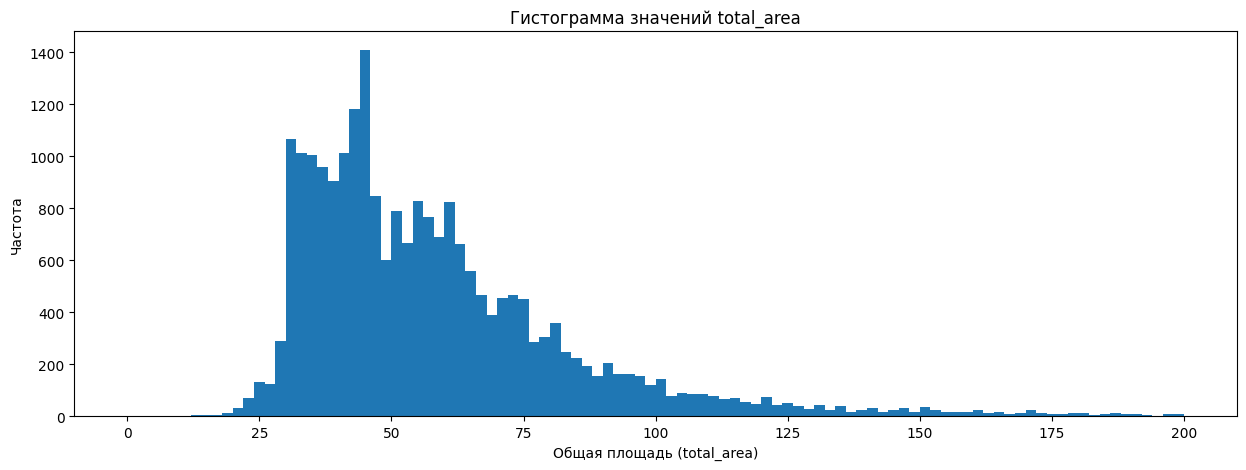

In [46]:
plt.figure(figsize=(15, 5))
# Общая площадь
print(data['total_area'].hist(bins=100, range=(0, 200)))
plt.title('Гистограмма значений total_area')  # Заголовок графика
plt.xlabel('Общая площадь (total_area)')  # Подпись оси X
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

In [47]:
data['total_area'].describe().round()

count    23189.0
mean        60.0
std         36.0
min         12.0
25%         40.0
50%         52.0
75%         70.0
max        900.0
Name: total_area, dtype: float64

In [48]:
# Анализ максимальных площадей и их цен
# Группировка по 'total_area'
grouped_data = data.groupby('total_area')['last_price'].agg(
    count='count',
    mean='mean',
    last_value=lambda x: x.iloc[-1]
)

# Сортировка по убыванию по последнему значению
sorted_data = grouped_data.sort_values(by='total_area', ascending=False)

# Печать отсортированных результатов
sorted_data.head()
sorted_data.tail()

,count,mean,last_value
total_area,,,
16.0,1,2.100000e+06,2100000.0
15.0,3,1.966667e+06,1550000.0
14.0,1,1.190000e+06,1190000.0
13.0,4,2.184000e+06,3800000.0
12.0,1,2.400000e+06,2400000.0


In [49]:
data['total_area'].describe().round()

count    23189.0
mean        60.0
std         36.0
min         12.0
25%         40.0
50%         52.0
75%         70.0
max        900.0
Name: total_area, dtype: float64

In [50]:
# Группировка по 'last_price' и агрегация
grouped_data = data.groupby('last_price')['total_area'].agg(
    count='count',
    last_value=lambda x: x.iloc[-1]
)

# Сортировка по убыванию по последнему значению
sorted_data = grouped_data.sort_values(by='last_value', ascending=False)

# Печать отсортированных результатов
print(sorted_data.head(10))
print(sorted_data.tail(10))

             count  last_value
last_price                    
420000000.0      1       900.0
140000000.0      3       631.0
300000000.0      1       618.0
84000000.0       1       507.0
150000000.0      2       500.0
230000000.0      1       500.0
91500000.0       1       495.0
43185328.0       1       494.0
91075000.0       1       491.0
99000000.0       2       488.0
            count  last_value
last_price                   
1810000.0       1        22.0
2680000.0       7        22.0
1680000.0       6        21.0
1811250.0       1        20.0
1870000.0       3        20.0
945750.0        1        19.0
770000.0        1        18.0
1737000.0       1        17.0
1190000.0       2        14.0
1686000.0       1        13.0


In [51]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.1519895354234393

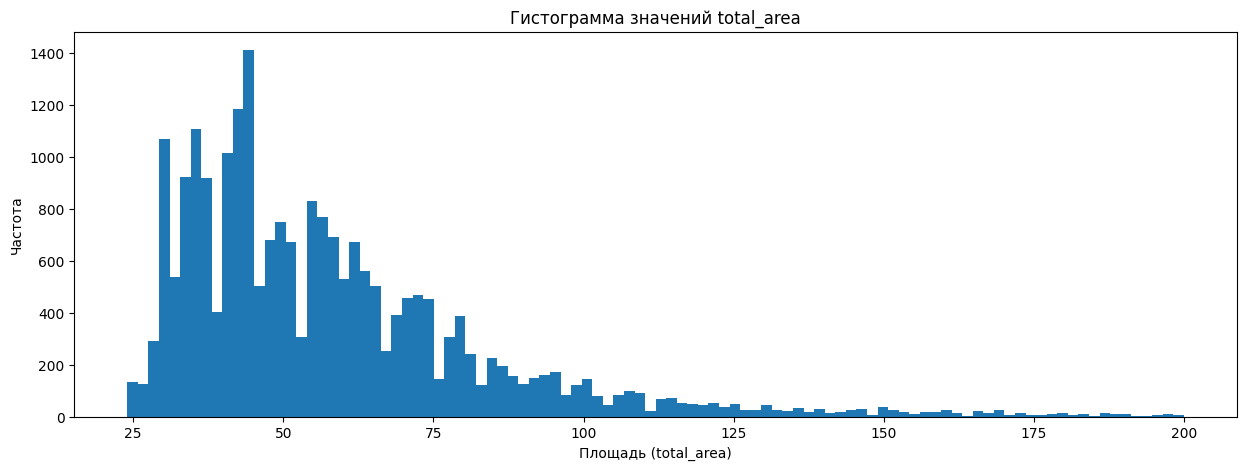

In [52]:
plt.figure(figsize=(15, 5))
data['total_area'].hist(bins=(100), range=(24, 200))
plt.title('Гистограмма значений total_area')  # Заголовок графика
plt.xlabel('Площадь (total_area)')  # Подпись оси X
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

Анализ редких площадей и их цен показал, что удалять аномальные значения не нужно. Т.к. порядок цен может меняться данных пределах - квартира может обладать характеристиками, повышающими или понижающими цену. Люди могут продавать и 900 метровую недвижимость, и 8миметровую.  Пропусков в общей площади нет. Эти данные одни из самых важных при выборе кваритиры.
проведем анализ далее.

In [53]:
# Проверим % потери данных
100-(data.shape[0] / 23699)*100

2.1519895354234393

**Жилая площадь**

In [54]:
# Жилая площадь 'living_area'
print(sorted(data['living_area'].unique(), reverse=True))

[np.float64(nan), np.float64(409.7), np.float64(409.0), np.float64(347.5), np.float64(332.0), np.float64(322.3), np.float64(312.5), np.float64(301.5), np.float64(300.0), np.float64(279.6), np.float64(274.0), np.float64(264.5), np.float64(260.0), np.float64(258.0), np.float64(255.7), np.float64(250.0), np.float64(248.7), np.float64(248.5), np.float64(239.4), np.float64(230.0), np.float64(225.9), np.float64(222.0), np.float64(220.0), np.float64(218.0), np.float64(216.0), np.float64(211.0), np.float64(204.0), np.float64(200.0), np.float64(199.0), np.float64(198.0), np.float64(195.0), np.float64(194.0), np.float64(193.5), np.float64(193.0), np.float64(190.0), np.float64(189.4), np.float64(188.7), np.float64(187.9), np.float64(187.0), np.float64(184.9), np.float64(184.0), np.float64(183.7), np.float64(183.0), np.float64(182.8), np.float64(182.0), np.float64(181.8), np.float64(180.0), np.float64(179.2), np.float64(179.0), np.float64(177.3), np.float64(177.0), np.float64(176.6), np.float64(17

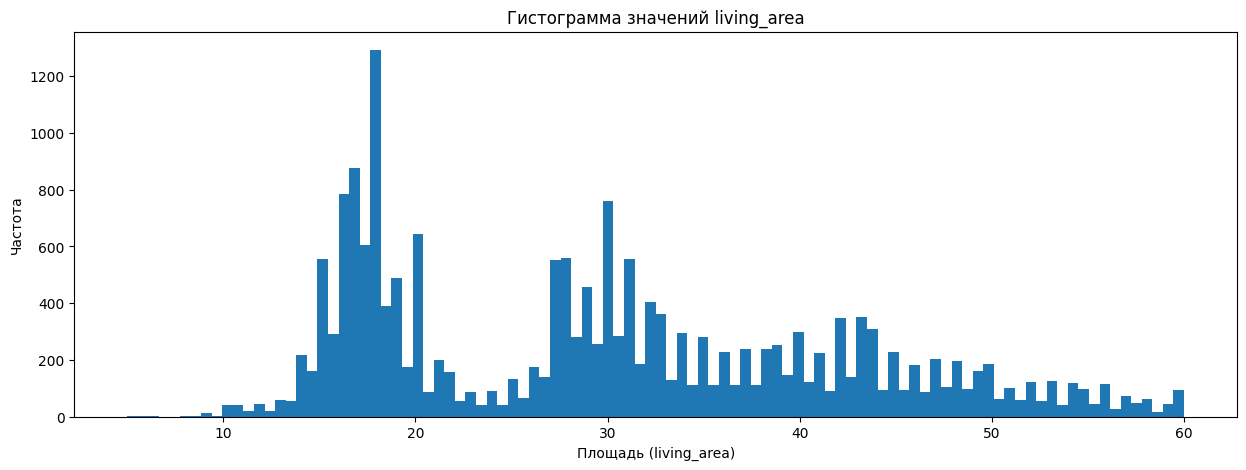

In [55]:
plt.figure(figsize=(15, 5))
data['living_area'].hist(bins=(100), range=(5, 60))
plt.title('Гистограмма значений living_area')  # Заголовок графика
plt.xlabel('Площадь (living_area)')  # Подпись оси X
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

In [56]:
data['living_area'].describe()

count    21364.000000
mean        34.495757
std         22.178844
min          2.000000
25%         18.600000
50%         30.000000
75%         42.400000
max        409.700000
Name: living_area, dtype: float64

In [57]:
data['living_area'].value_counts().sort_index(ascending=False)

living_area
409.7    1
409.0    1
347.5    1
332.0    1
322.3    1
        ..
6.0      1
5.4      1
5.0      1
3.0      2
2.0      2
Name: count, Length: 1762, dtype: int64

Недвижимость может быть как квартирами, так и комнатами, аппаратментами и тд. Согласно действующим на момент продаж СНиПам, минимальная площадь комнаты должна быть не менее 8 квадратных метров (п. 5.3 СП 5.413330.2011), при этом её ширина не должна быть меньше 2,25 метра (п 6.1.9 СП 31-107-2004) При несоблюдении хотя бы одного из этих условий, считать комнату жилой нельзя.

In [58]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.1519895354234393

In [59]:
# Проверим количество жилых помещений площадью менее 8 кв м
(data['living_area'] < 8).sum()

np.int64(8)

In [60]:
# По закону на годы продаж жилая площадь ме может быть меньше 8 кв м.
# Оставим строки с площадями 8 кв м. и более и с пропусками
data = data[(data['living_area'] >= 8) | (data['living_area'].isna())]

In [61]:
# Проверим % потери данных
100-(data.shape[0] / 23699)*100

2.1857462340183105

In [62]:
# Проверим количество жилых помещений площадью менее 8 кв м
(data['living_area'] < 8).sum()

np.int64(0)

In [63]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.1857462340183105

Жилая площадь в большинстве случаев находится в диапазоне 30 кв м.

Удалены строки с площадями менее 8 м кв.

Потеря данных менее 10-15%. Допустимо. Продлолжаем исследование.

**Площадь кухни**

In [64]:
# Площадь кухни 'kitchen_area'
print(sorted(data['kitchen_area'].unique(), reverse=True))

[np.float64(nan), np.float64(112.0), np.float64(107.0), np.float64(100.7), np.float64(100.0), np.float64(93.2), np.float64(93.0), np.float64(87.2), np.float64(77.0), np.float64(75.0), np.float64(72.0), np.float64(70.0), np.float64(66.0), np.float64(65.0), np.float64(64.0), np.float64(63.4), np.float64(63.0), np.float64(62.5), np.float64(62.0), np.float64(60.0), np.float64(58.4), np.float64(58.0), np.float64(56.2), np.float64(56.0), np.float64(55.7), np.float64(55.5), np.float64(54.3), np.float64(54.2), np.float64(54.0), np.float64(53.1), np.float64(53.0), np.float64(51.8), np.float64(51.0), np.float64(50.2), np.float64(50.0), np.float64(49.4), np.float64(49.2), np.float64(48.5), np.float64(48.3), np.float64(48.0), np.float64(47.0), np.float64(46.8), np.float64(46.0), np.float64(45.5), np.float64(45.0), np.float64(44.9), np.float64(44.7), np.float64(44.0), np.float64(43.8), np.float64(43.4), np.float64(43.2), np.float64(43.0), np.float64(42.8), np.float64(42.7), np.float64(42.6), np.flo

In [65]:
# Группировка по 'last_price' и агрегация
grouped_data_kitchen_area = data.groupby('kitchen_area')['total_area'].agg(
    count='count',
    last_value_total_area=lambda x: x.iloc[-1]
)
# Сортировка по убыванию по последнему значению
sorted_data_total_area = grouped_data_kitchen_area.sort_values(by='last_value_total_area', ascending=False)

# Печать отсортированных результатов
print(sorted_data_total_area.head(10))
print(sorted_data_total_area.tail(10))

              count  last_value_total_area
kitchen_area                              
112.00            1                  900.0
70.00             2                  618.0
100.00            1                  590.0
45.50             1                  507.0
55.50             1                  460.0
35.05             1                  441.0
27.60             1                  374.0
51.00             3                  374.0
37.00             5                  365.0
27.10             1                  327.0
              count  last_value_total_area
kitchen_area                              
1.30              1                   28.0
8.13              1                   28.0
5.74              1                   27.0
14.17             1                   25.0
4.70              6                   25.0
5.00            342                   23.0
3.00              7                   23.0
14.95             1                   20.0
2.00              7                   20.0
2.40       

In [66]:
data['kitchen_area'].describe().round()

count    20985.0
mean        11.0
std          6.0
min          1.0
25%          7.0
50%          9.0
75%         12.0
max        112.0
Name: kitchen_area, dtype: float64

In [67]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.1857462340183105

In [68]:
# Удалим аномально маленькие площади кухонь, которых быть в квартирах не может, и оставим пропуски
data = data[(data['kitchen_area'] >= 5) | (data['kitchen_area'].isna())]
print(sorted(data['kitchen_area'].unique(), reverse=True))

[np.float64(nan), np.float64(112.0), np.float64(107.0), np.float64(100.7), np.float64(100.0), np.float64(93.2), np.float64(93.0), np.float64(87.2), np.float64(77.0), np.float64(75.0), np.float64(72.0), np.float64(70.0), np.float64(66.0), np.float64(65.0), np.float64(64.0), np.float64(63.4), np.float64(63.0), np.float64(62.5), np.float64(62.0), np.float64(60.0), np.float64(58.4), np.float64(58.0), np.float64(56.2), np.float64(56.0), np.float64(55.7), np.float64(55.5), np.float64(54.3), np.float64(54.2), np.float64(54.0), np.float64(53.1), np.float64(53.0), np.float64(51.8), np.float64(51.0), np.float64(50.2), np.float64(50.0), np.float64(49.4), np.float64(49.2), np.float64(48.5), np.float64(48.3), np.float64(48.0), np.float64(47.0), np.float64(46.8), np.float64(46.0), np.float64(45.5), np.float64(45.0), np.float64(44.9), np.float64(44.7), np.float64(44.0), np.float64(43.8), np.float64(43.4), np.float64(43.2), np.float64(43.0), np.float64(42.8), np.float64(42.7), np.float64(42.6), np.flo

In [69]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

In [70]:
data['kitchen_area'].describe()

count    20882.000000
mean        10.653729
std          5.927362
min          5.000000
25%          7.100000
50%          9.300000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

In [71]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

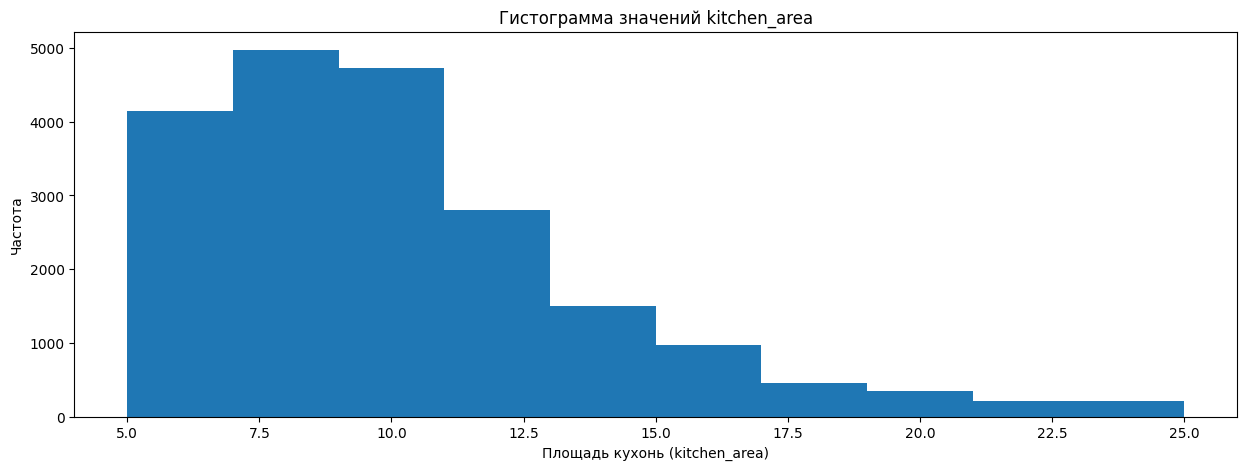

In [72]:
plt.figure(figsize=(15, 5))
data['kitchen_area'].hist(bins=10, range=(5, 25))
plt.title('Гистограмма значений kitchen_area')  # Заголовок графика
plt.xlabel('Площадь кухонь (kitchen_area)')  # Подпись оси X
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

In [73]:
data['kitchen_area'].describe()

count    20882.000000
mean        10.653729
std          5.927362
min          5.000000
25%          7.100000
50%          9.300000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

In [74]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

Площади кухонь соответствуют площадям квартир, в том числе, большие площади кухонь. Поэтому их не удаляем.

Основная масса кухонь 7-9-12 кв м.

Маленькие площади кухонь - менее 5 кв м - строки с этими кухнями удалили - квартир с такими кухнями на рынке нет.

Так же можно удалить строки с кухнями, большими или равными, чем общая площадь квартиры, но пока отложим проверку.

Данных после проделанной работы удалено менее 15%, продолжим анализ

**Цены объектов недвижимости**

In [75]:
# Цена объекта

# Группировка по 'last_price' и агрегация
grouped_data_last_price = data.groupby('total_area')['last_price'].agg(
    count='count',
    last_value_last_price=lambda x: x.iloc[-1]
)
# Сортировка по убыванию по последнему значению
sorted_data_last_price = grouped_data_last_price.sort_values(by='last_value_last_price', ascending=False)

# Печать отсортированных результатов
sorted_data_last_price.head(10)
sorted_data_last_price.tail(10)

,count,last_value_last_price
total_area,,
20.0,14,2300000.0
19.0,3,2190000.0
16.0,1,2100000.0
17.0,4,2050000.0
21.0,16,2000000.0
18.0,7,1900000.0
46.0,502,1650000.0
15.0,3,1550000.0
30.0,429,1350000.0


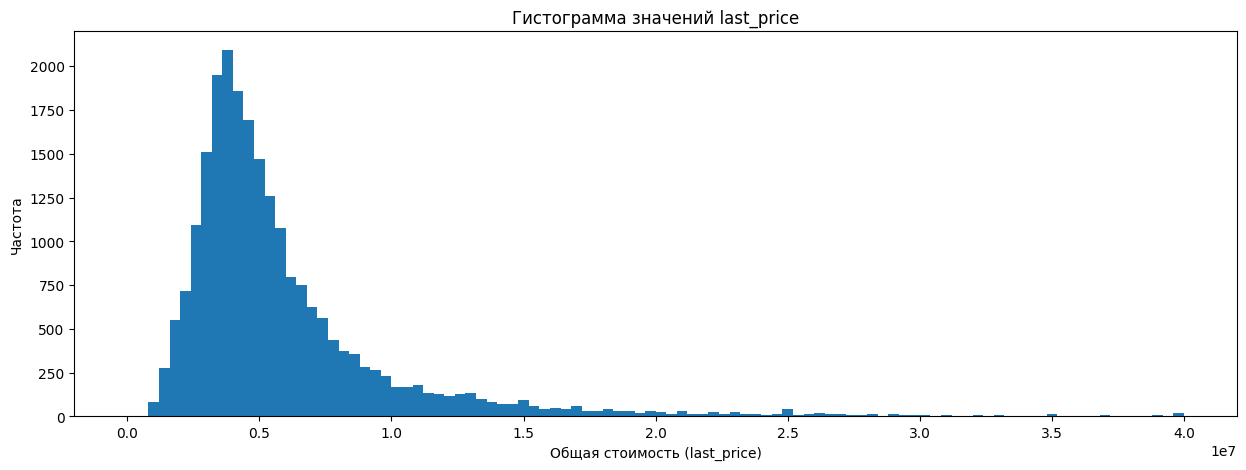

In [76]:
plt.figure(figsize=(15, 5))
data['last_price'].hist(bins=100, range=(0, 40000000))
plt.title('Гистограмма значений last_price')  # Заголовок графика
plt.xlabel('Общая стоимость (last_price)')  # Подпись оси X
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

In [77]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

Для цен на квартиры есть сильные выбросы. Далее будет приведен более глубокий анализ - месторасположения квартиры и тд. Кроме того, сделки порядка 1000 000+- за квартиру вызывают подозрения и должны быть проверены соответствующими органами на предмет мошенничества или насилия.

**Высота потолков**

In [78]:
# Высота потолков
# Проверим на аномалии - если потолки больше 5 м - это аномалия, разберемся и устраним 
# ее или удалим строки
# Сортировка по 'ceiling_height' по убыванию
sorted_data = data.sort_values(by='ceiling_height', ascending=False)

# Группировка и получение первых 30 значений
grouped_data = sorted_data.groupby('ceiling_height').head()

# Печать только значений 'ceiling_height'
grouped_data['ceiling_height'].head(10)

22869    100.0
3148      32.0
22336     32.0
21377     27.5
20478     27.0
5246      27.0
17857     27.0
4876      27.0
22938     27.0
5669      26.0
Name: ceiling_height, dtype: float64

In [79]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

In [80]:
# Количество объектов с высотами потолков:
data['ceiling_height'].value_counts().to_frame()

,count
ceiling_height,
2.50,3375
2.60,1611
2.70,1560
3.00,1089
2.80,987
...,...
3.48,1
10.30,1
1.00,1


In [81]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

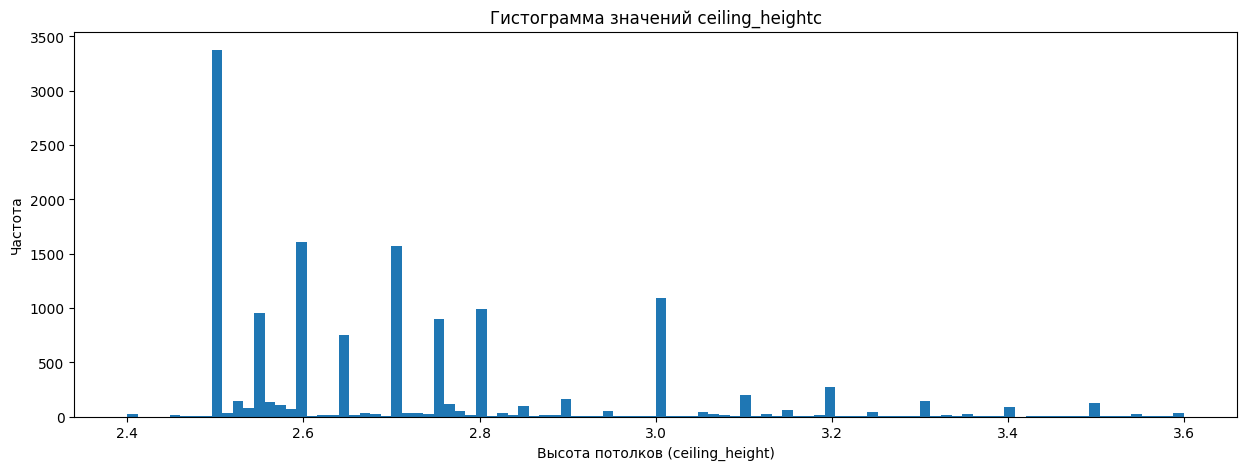

In [82]:
plt.figure(figsize=(15, 5))
data['ceiling_height'].hist(bins=100, range=(2.4, 3.6))
plt.title('Гистограмма значений ceiling_heightc')  # Заголовок графика
plt.xlabel('Высота потолков (ceiling_height)')  # Подпись оси X
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

Анализ высот потолков показал аномальные значения. Высоту, например, 100 м ничем не заменишь - удалим строки с подобными значениями. Вымоты 27 и подобные заменим на 2.7 - ошибка внечения данных- человеческий фактор. 

После исправления удалим квартиры с потолками высотой менее 2.4 м и более 5 м

In [83]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

In [84]:
def def_ceiling_height(height):
    if 0 <= height <= 2.4:
        return None  # Удаляем
    elif 2.4 < height <= 5:
        return height  # Оставляем как есть
    elif 5 < height < 24:
        return None  # Удаляем
    elif 24.0 <= height <= 50.0:
        return height*0.1  # Делим на 10
    elif height > 50:
        return None  # Удаляем
    else:
        return None  # На всякий случай, если высота отрицательная или с неучтенной аномалией
    
# Применение функции к столбцу 'ceiling_height'
data['ceiling_height'] = data['ceiling_height'].apply(def_ceiling_height)


In [85]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

In [86]:
data['ceiling_height'].describe()

count    14152.000000
mean         2.728765
std          0.271029
min          2.400000
25%          2.530000
50%          2.650000
75%          2.800000
max          4.900000
Name: ceiling_height, dtype: float64

In [87]:
# Проверим количество пропусков в ceiling_height'
data['ceiling_height'].isna().sum()

np.int64(8926)

In [88]:
#  ОШИБКА_ ТЕРЯЛИСЬ ДАННЫЕ
# Удаление строк с высотой потолков больше 5 м и меньше 2.4 м
#data = data[(data['ceiling_height'] <= 5) & (data['ceiling_height'] >= 2.4)]


# Заполним пропуски высот потолков медианными значениями
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())


In [89]:
# Проверим количество пропусков в ceiling_height'
data['ceiling_height'].isna().sum()

np.int64(0)

In [90]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

In [91]:
# Печать результата
print(sorted(data['ceiling_height'].unique(), reverse=True))

[np.float64(4.9), np.float64(4.8), np.float64(4.7), np.float64(4.65), np.float64(4.5), np.float64(4.45), np.float64(4.4), np.float64(4.37), np.float64(4.3), np.float64(4.25), np.float64(4.2), np.float64(4.19), np.float64(4.15), np.float64(4.14), np.float64(4.1), np.float64(4.06), np.float64(4.0), np.float64(3.98), np.float64(3.95), np.float64(3.93), np.float64(3.9), np.float64(3.88), np.float64(3.87), np.float64(3.86), np.float64(3.85), np.float64(3.84), np.float64(3.83), np.float64(3.82), np.float64(3.8), np.float64(3.78), np.float64(3.76), np.float64(3.75), np.float64(3.7), np.float64(3.69), np.float64(3.68), np.float64(3.67), np.float64(3.66), np.float64(3.65), np.float64(3.63), np.float64(3.62), np.float64(3.6), np.float64(3.59), np.float64(3.58), np.float64(3.57), np.float64(3.56), np.float64(3.55), np.float64(3.54), np.float64(3.53), np.float64(3.52), np.float64(3.51), np.float64(3.5), np.float64(3.49), np.float64(3.48), np.float64(3.47), np.float64(3.46), np.float64(3.45), np.fl

In [92]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

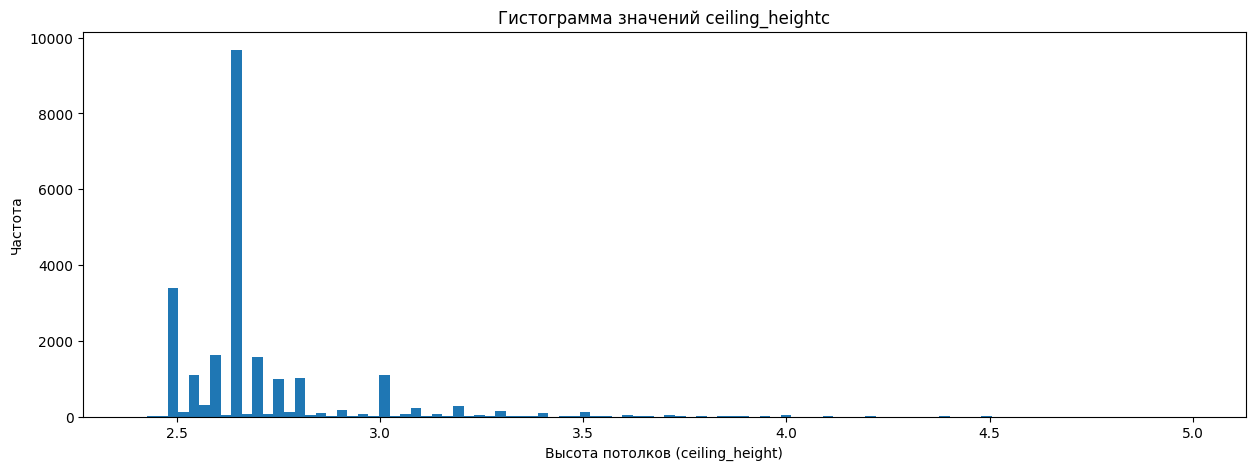

In [93]:
plt.figure(figsize=(15, 5))
data['ceiling_height'].hist(bins=100, range=(2.4, 5))
plt.title('Гистограмма значений ceiling_heightc')  # Заголовок графика
plt.xlabel('Высота потолков (ceiling_height)')  # Подпись оси X
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

In [94]:
# Проверка изменения высоты потолков
def_ceiling_height(25.0)

2.5

Заполним высоту потолков наиболее часто встречающейся - медианной. Это лучше нуля, тк нулевой высоты потолки быть не могут.

In [95]:
# Заполним высоту потолков наиболее часто встречающейся - медианной.
# data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())
# print(sorted(data['ceiling_height'].unique(), reverse=True))

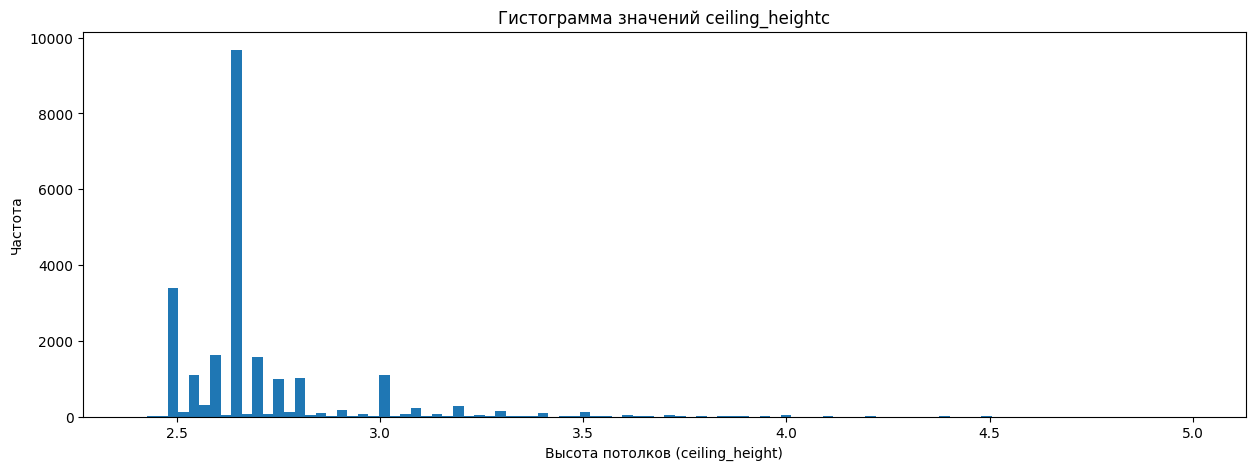

In [96]:
plt.figure(figsize=(15, 5))
data['ceiling_height'].hist(bins=100, range=(2.4, 5))
plt.title('Гистограмма значений ceiling_heightc')  # Заголовок графика
plt.xlabel('Высота потолков (ceiling_height)')  # Подпись оси X
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

Проверка показала, что значения потолков приведены к значениям от 2.4 м до 5 м.

In [97]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

**Тип этажа квартиры floor_type («первый», «последний», «другой»)**

In [98]:
# Тип этажа квартиры floor_type («первый», «последний», «другой»)
print(data.apply(def_floor_type, axis=1).head())

0    НЕТ ДАННЫХ
1        первый
2    НЕТ ДАННЫХ
3    НЕТ ДАННЫХ
4    НЕТ ДАННЫХ
dtype: object


<Axes: ylabel='count'>

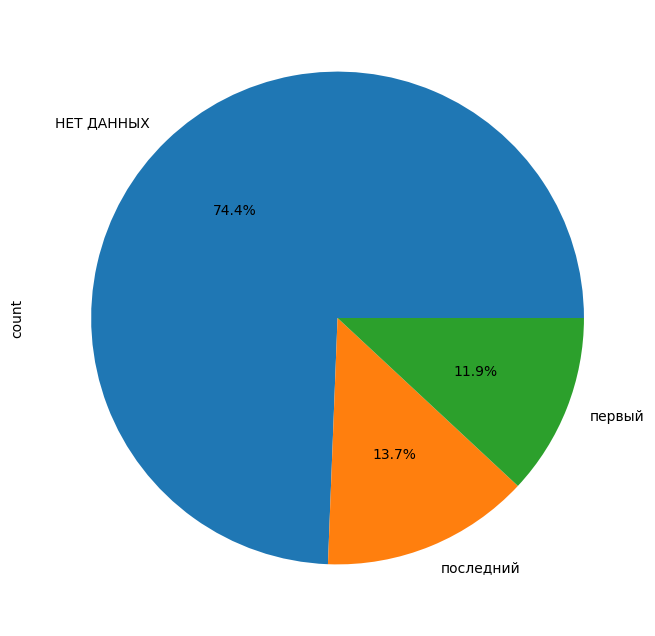

In [99]:
data['floor_type'].value_counts().plot(kind='pie', y='count', figsize=(8, 8), autopct='%1.1f%%')

Первых этажей продается меньше всего, последних больше и остальных - максимальное количество.

In [100]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.6203637284273498

**Общее количество этажей в доме**

In [101]:
# Общее количество этажей в доме
data['floors_total'].value_counts().to_frame()

,count
floors_total,
5.0,5469
9.0,3735
16.0,1373
12.0,1360
10.0,1173
4.0,1149
25.0,1070
6.0,899
17.0,832


В Санкт-Петербурге и области самое высокое жилое здание "Александр Невский" имеет 35 этажей. Поэтому сгруппируем по этажности дома 

Анализ показал малое количество квартир с этажностью выше 35 этажа, кроме того, рассматривается жилая недвижимость. Она на 0 этаже быть не может - удаляем строки с этими аномалиями.

In [102]:
# Фильтрация данных: оставляем строки с floors_total <= 35 или с пропусками
data = data[(data['floors_total'] <= 35) | (data['floors_total'].isna())]

In [103]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.645681252373521

In [104]:
data['floors_total'].describe()

count    22988.000000
mean        10.807073
std          6.567589
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         35.000000
Name: floors_total, dtype: float64

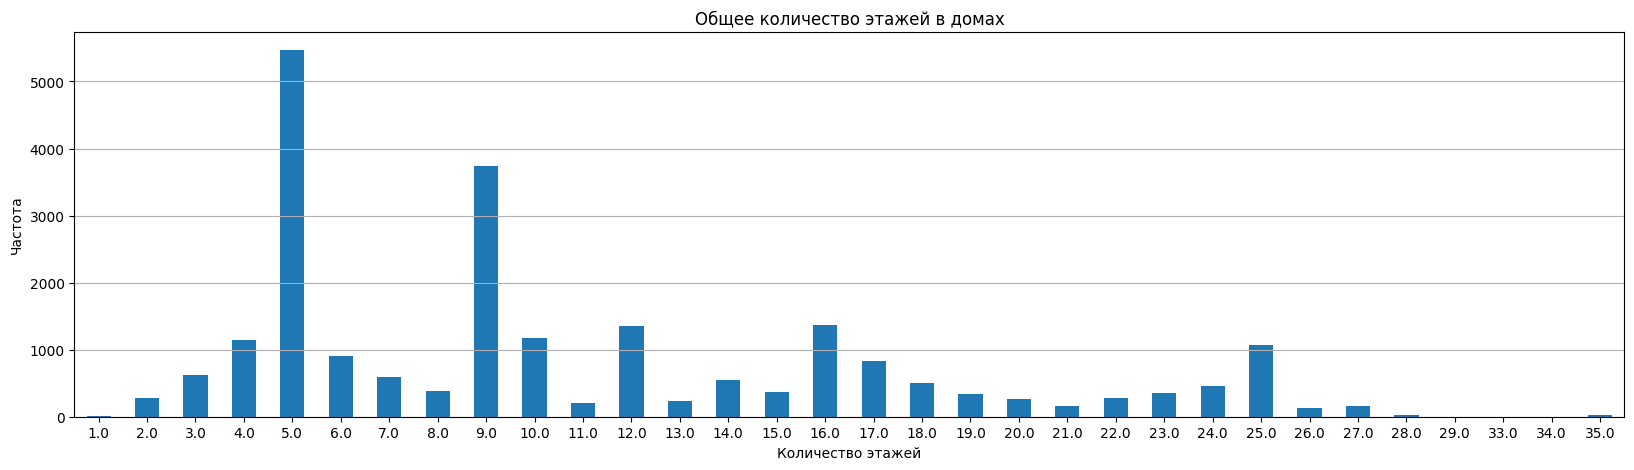

In [105]:
# Подсчет количества уникальных значений в floors_total
floor_counts = data['floors_total'].value_counts().sort_index()

# Построение графика
plt.figure(figsize=(20, 5))  # Установка размера графика
floor_counts.plot(kind='bar')  # Построение столбчатой диаграммы

# Установка заголовка и меток осей
plt.title('Общее количество этажей в домах')
plt.xlabel('Количество этажей')
plt.ylabel('Частота')
plt.xticks(rotation=0)  # Установка угла поворота меток по оси X
plt.grid(axis='y')  # Включение сетки по оси Y
plt.show()  # Отображение графика

In [106]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.645681252373521

Анализ далее будет проводиться для объектов с этажами от 0 до 35го. Аномалии устранены.

После проведенной работы удалено менее 15% данных. Продолжим исследование.

**Расстояние до центра города в метрах 'cityCenters_nearest'**

In [107]:
# Расстояние до центра города в метрах 'cityCenters_nearest'
# не понятно какое расстояние задано - в каждом городе свой центр или центр Петербурга. 
# будем считать, Петербурга, т.к. воспользуемся правилами русского языка и логикой - 
# до центра города - надо взять один город, логика - логичнее взять самый большой город 
# областной центр
print(data['cityCenters_nearest'].head())

0    16028.0
1    18603.0
2    13933.0
3     6800.0
4     8098.0
Name: cityCenters_nearest, dtype: float64


In [108]:
# Проанализируем минимальное и максимальное расстояния до центра
print(sorted(data['cityCenters_nearest'].unique(), reverse=True))

[np.float64(nan), np.float64(65968.0), np.float64(65952.0), np.float64(65764.0), np.float64(65105.0), np.float64(64857.0), np.float64(62706.0), np.float64(62454.0), np.float64(61495.0), np.float64(60223.0), np.float64(59626.0), np.float64(59052.0), np.float64(56745.0), np.float64(54926.0), np.float64(54646.0), np.float64(54490.0), np.float64(54214.0), np.float64(53568.0), np.float64(53379.0), np.float64(53294.0), np.float64(53177.0), np.float64(53138.0), np.float64(53132.0), np.float64(53104.0), np.float64(53078.0), np.float64(53028.0), np.float64(52974.0), np.float64(52968.0), np.float64(52943.0), np.float64(52900.0), np.float64(52895.0), np.float64(52858.0), np.float64(52818.0), np.float64(52768.0), np.float64(52717.0), np.float64(52716.0), np.float64(52696.0), np.float64(52628.0), np.float64(52380.0), np.float64(52334.0), np.float64(52328.0), np.float64(52259.0), np.float64(52222.0), np.float64(52206.0), np.float64(52179.0), np.float64(52143.0), np.float64(52136.0), np.float64(52120

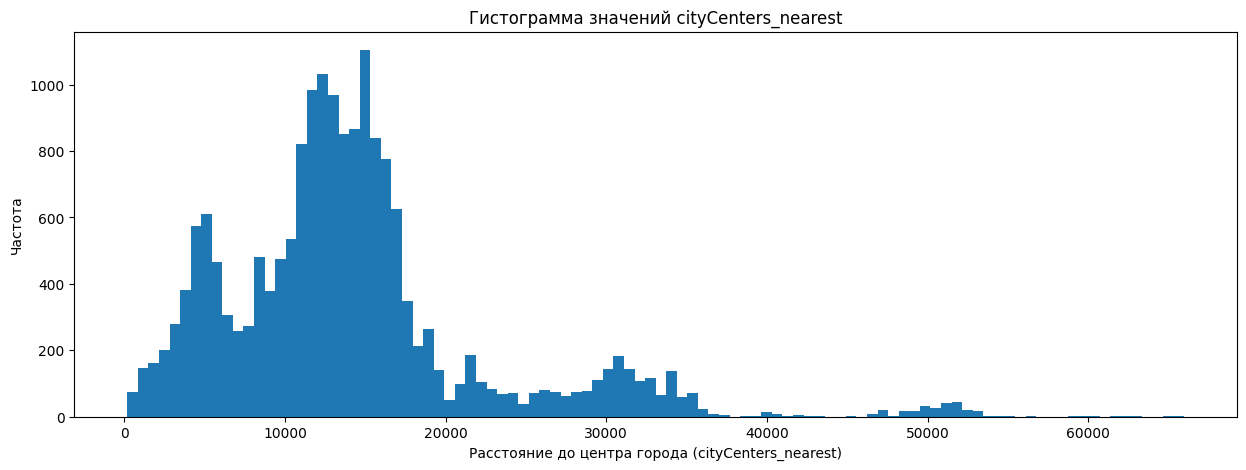

In [109]:
plt.figure(figsize=(15, 5))
data['cityCenters_nearest'].hist(bins=100, )
plt.title('Гистограмма значений cityCenters_nearest')  # Заголовок графика
plt.xlabel('Расстояние до центра города (cityCenters_nearest)')  # Подпись оси X
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

In [110]:
data['cityCenters_nearest'].value_counts()

cityCenters_nearest
8460.0     61
20802.0    31
10720.0    30
8434.0     27
8370.0     26
           ..
3764.0      1
4566.0      1
8499.0      1
5956.0      1
1225.0      1
Name: count, Length: 7593, dtype: int64

In [111]:
data['cityCenters_nearest'].describe()

count    18049.000000
mean     14184.619813
std       8576.235118
min        181.000000
25%       9241.000000
50%      13105.000000
75%      16293.000000
max      65968.000000
Name: cityCenters_nearest, dtype: float64

In [112]:
# Проверим % потери данных
100 - (data.shape[0] / 23699)*100

2.645681252373521

Расстояние до центра равно 13 км.

Есть пропуски. Их мы не исправляем. Не удаляем. А строки с объектами без указанного расстояния нам еще прогодятся.

БОльшая часть объектов находится от центра в диапазоне расстояний от 9 до 16 км.

Данных удалено менее 15%. Продолжим.

**Расстояние до ближайшего парка 'parks_nearest'**

In [113]:
# Расстояние до ближайших парков
data['parks_nearest'].value_counts().to_frame()

,count
parks_nearest,
441.0,67
173.0,41
392.0,41
456.0,40
471.0,32
...,...
755.0,1
1073.0,1
1568.0,1


In [114]:
print(data['parks_nearest'].head())

0    482.0
1      NaN
2     90.0
3     84.0
4    112.0
Name: parks_nearest, dtype: float64


In [115]:
print(sorted(data['parks_nearest'].unique(), reverse=True))

[np.float64(nan), np.float64(3190.0), np.float64(3064.0), np.float64(3013.0), np.float64(2984.0), np.float64(2905.0), np.float64(2888.0), np.float64(2880.0), np.float64(2847.0), np.float64(2768.0), np.float64(2747.0), np.float64(2711.0), np.float64(2665.0), np.float64(2633.0), np.float64(2555.0), np.float64(2532.0), np.float64(2489.0), np.float64(2467.0), np.float64(2427.0), np.float64(2416.0), np.float64(2409.0), np.float64(2348.0), np.float64(2295.0), np.float64(2276.0), np.float64(2245.0), np.float64(2218.0), np.float64(2209.0), np.float64(2137.0), np.float64(2131.0), np.float64(2102.0), np.float64(2066.0), np.float64(2026.0), np.float64(2009.0), np.float64(1951.0), np.float64(1942.0), np.float64(1909.0), np.float64(1887.0), np.float64(1809.0), np.float64(1802.0), np.float64(1798.0), np.float64(1790.0), np.float64(1767.0), np.float64(1756.0), np.float64(1731.0), np.float64(1722.0), np.float64(1657.0), np.float64(1648.0), np.float64(1620.0), np.float64(1596.0), np.float64(1586.0), np

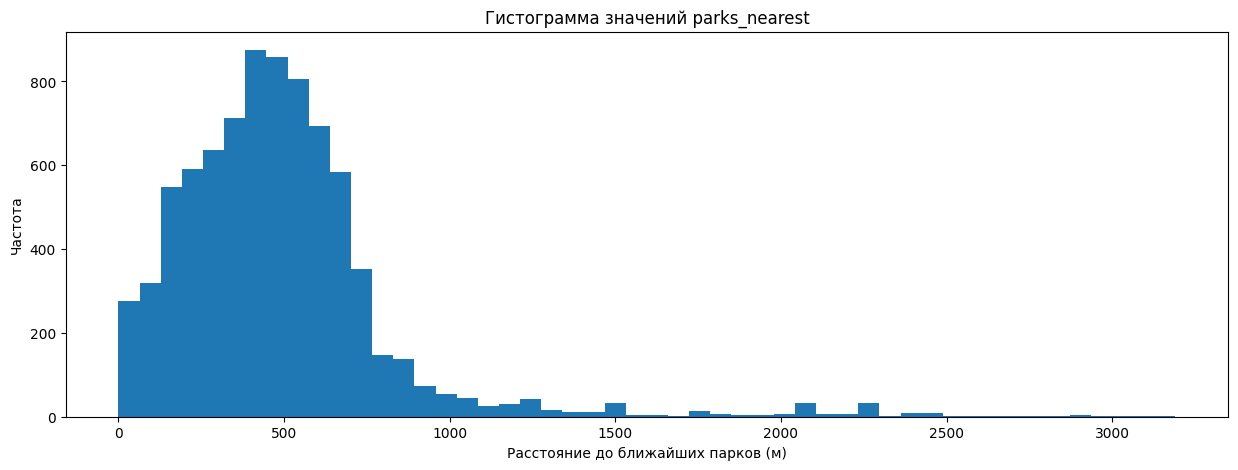

In [116]:
# Построение гистограммы
plt.figure(figsize=(15, 5))  # Установка размера графика
data['parks_nearest'].hist(bins=50)  # Построение гистограммы с 50 корзинами

# Установка заголовка и меток осей
plt.title('Гистограмма значений parks_nearest')  # Исправлено: добавлена закрывающая кавычка
plt.xlabel('Расстояние до ближайших парков (м)')
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

У бОльшей части квартир и парки находятся на расстоянии 400 - 600 м. 
Квартир с парками с нулевым расстоянием - нан - 482 шт. ** Если данная выборка будет мешать анализу, удалим строки с 0 значением расстояний до парка. Пока оставим.

In [117]:
100 - (data.shape[0] / 23699)*100

2.645681252373521

_____________________________________________________________________________

Изучим **как быстро продавались квартиры** (столбец days_exposition). Этот параметр показывает, сколько дней было размещено каждое объявление. 

o	Построим гистограмму.

o	Посчитаем среднее и медиану.

o	Опишем сколько времени обычно занимает продажа. Какие продажи можно считать быстрыми, а какие — необычно долгими?

**Длительность продаж квартир (дней)**

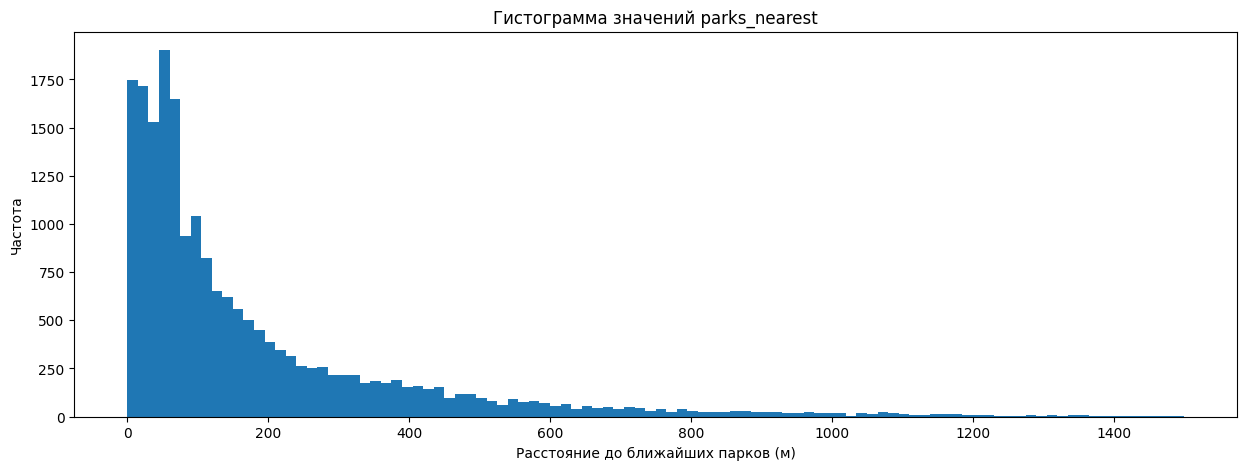

In [118]:
# Построение гистограммы
plt.figure(figsize=(15, 5))  # Установка размера графика
data['days_exposition'].hist(bins=100, range=(0, 1500))

# Установка заголовка и меток осей
plt.title('Гистограмма значений parks_nearest')  # Исправлено: добавлена закрывающая кавычка
plt.xlabel('Расстояние до ближайших парков (м)')
plt.ylabel('Частота')  # Подпись оси Y
plt.grid(False)  # Отключение сетки
plt.show()  # Отображение графика

In [119]:
data['days_exposition'].describe().round()

count    19995.0
mean       181.0
std        220.0
min          1.0
25%         45.0
50%         95.0
75%        231.0
max       1580.0
Name: days_exposition, dtype: float64

Обычно продаже недвижимости занимает 95 дней.

Продажи длительностью 44 дня и меньше можно считать быстрыми, а длительностью от 232 дней - необычно долгими.

**Длительность продаж квартир (дней)  в зависимости от населенного пункта**

In [120]:
grouped_data_days_exposition = data.groupby(['locality_name'])['days_exposition'].agg(
    count='count',
    median='median',
    mean='mean',
)
# Сортировка по убыванию по последнему значению
sorted_data_days_exposition = grouped_data_days_exposition.sort_values(by='median', ascending=False).round()

# Печать отсортированных результатов
print(sorted_data_days_exposition.head())
print(sorted_data_days_exposition.tail())

                    count  median   mean
locality_name                           
п. Плодовое             2   454.0  454.0
п.г.т. Красный Бор      7   196.0  319.0
Приозерск              48   161.0  231.0
Федоровское            11   143.0  316.0
Павловск               31   134.0  248.0
               count  median   mean
locality_name                      
д. Кудрово       441    73.0  160.0
г.п. Янино-1      71    65.0  146.0
Кингисепп         94    54.0  130.0
д. Заклинье        1    46.0   46.0
д. Пикколово       1    45.0   45.0


In [121]:
# Функция для определения идентификатора города
def def_category(city):
    try:
        if city == 'г. Санкт-Петербург':
            return 0
        elif city == 'п. Шушары':
            return 1
        elif city == 'п. Парголово':
            return 2
        elif city == 'п. Мурино':
            return 3
        elif city == 'Ломоносов':
            return 4
        elif city == 'Сертолово':
            return 5
        elif city == 'Петергоф':
            return 6
        elif city == 'Пушкин':
            return 7
        elif city == 'д. Кудрово':
            return 8
        elif city == 'Коммунар':
            return 9
        elif city == 'Колпино':
            return 10
        elif city == 'п.г.т. Красный Бор':
            return 11
        elif city == 'Гатчина':
            return 12
        elif city == 'Федоровское':
            return 13
        elif city == 'г. Выборг':
            return 14
        elif city == 'г. Кронштадт':
            return 16
        elif city == 'Кировск':
            return 17
        elif city == 'д. Новое Девяткино':
            return 18
        elif city == 'п. Металлострой':
            return 19
        elif city == 'п.г.т. Лебяжье':
            return 20
        elif city == 'п.г.т. Сиверский':
            return 21
        elif city == 'п. Молодцово':
            return 22
        elif city == 'п.г.т. Кузьмоловский':
            return 23
        elif city == 'г.п. Янино-1':
            return 28
        elif city == 'сад.тов. Новая Ропша':
            return 29
        elif city == 'Павловск':
            return 30
        elif city == 'д. Пикколово':
            return 31
        elif city == 'Всеволожск':
            return 32
        elif city == 'Волхов':
            return 33
        elif city == 'Кингисепп':
            return 34
        elif city == 'Приозерск':
            return 35
        elif city == 'д. Куттузи':
            return 36
        elif city == 'п. Аннино':
            return 37
        elif city == 'п.г.т. Ефимовский':
            return 38
        elif city == 'п. Плодовое':
            return 39
        elif city == 'д. Заклинье':
            return 40
    except:
        return 'НЕТ ДАННЫХ'

# Добавление столбца 'locality_name_id' к DataFrame
data['locality_name_id'] = data['locality_name'].apply(def_category)

# Печать уникальных значений нового столбца
print(data['locality_name_id'].unique())

[ 0.  1. 28.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 16. 17.
 18. 19. nan 21. 22. 23. 29. 30. 31. 32. 33. 34. 35. 36. 39. 40.]


In [122]:
# Зависимость длительности продажи от населенного пункта
days_exposition_mean_city = data.groupby(['locality_name_id', 'locality_name'])['days_exposition'].agg(['mean', 'median']).round()
days_exposition_mean_city=days_exposition_mean_city.sort_values(by='median', ascending=False)
print(days_exposition_mean_city)
print('Медианное время продажи недвижимости составляет', data['days_exposition'].median(), 'дней')
print('Среднее время продажи недвижимости составляет', data['days_exposition'].mean().round(), 'дней')

                                        mean  median
locality_name_id locality_name                      
39.0             п. Плодовое           454.0   454.0
11.0             п.г.т. Красный Бор    319.0   196.0
35.0             Приозерск             231.0   161.0
13.0             Федоровское           316.0   143.0
30.0             Павловск              248.0   134.0
4.0              Ломоносов             219.0   132.0
7.0              Пушкин                209.0   130.0
9.0              Коммунар              247.0   126.0
29.0             сад.тов. Новая Ропша  124.0   124.0
32.0             Всеволожск            197.0   123.0
17.0             Кировск               178.0   122.0
18.0             д. Новое Девяткино    189.0   112.0
33.0             Волхов                165.0   108.0
23.0             п.г.т. Кузьмоловский  178.0   106.0
19.0             п. Металлострой       158.0   100.0
12.0             Гатчина               189.0    99.0
6.0              Петергоф              205.0  

<Axes: xlabel='locality_name_id,locality_name'>

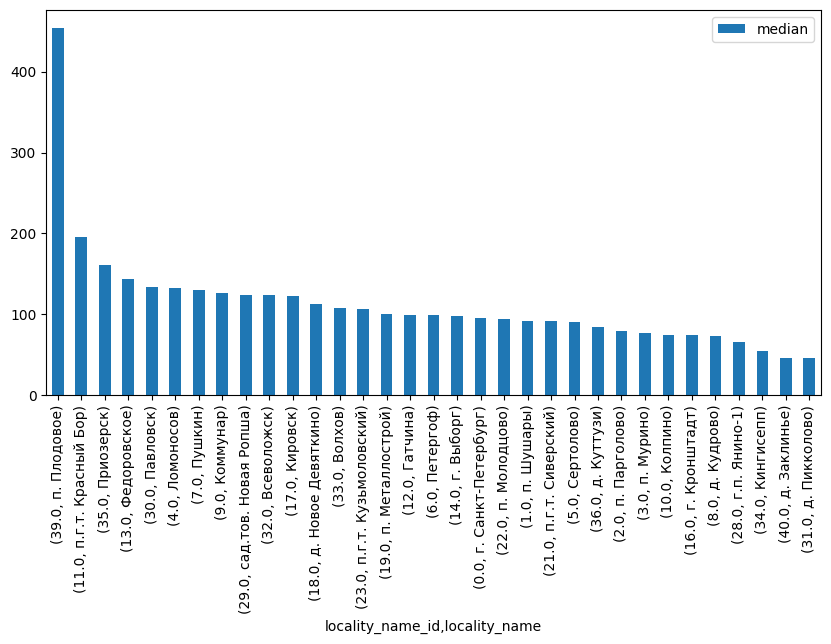

In [123]:
days_exposition_mean_city.sort_values(by='median', ascending=False).plot(
    y='median', 
    kind='bar', 
    figsize=(10, 5)
)

<Axes: xlabel='locality_name_id,locality_name'>

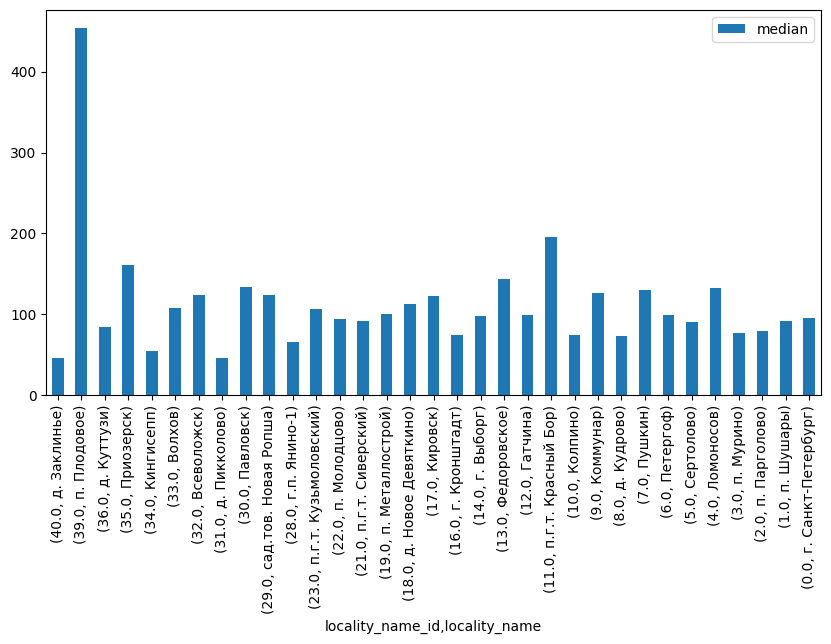

In [124]:
days_exposition_mean_city.sort_values(by='locality_name_id', ascending=False).plot(
    y='median', 
    kind='bar', 
    figsize=(10, 5)
)

Есть зависимость времени продажи недвижимости от населенного пункта. Чем дальше от столицы области находится населенный пункт, также чем больше отличается от города, тем дольше идут продажи.

**Зависимость длительности продажи от стоимости **

In [125]:
# Функция для определения ранжирования цен
def def_last_price(last_price):
    try:
        if 0 <= last_price <= 500000:
            return '0 - 500 000'
        elif 500001 <= last_price <= 1500000:
            return '500 000 - 1 500 000'
        elif 1500001 <= last_price <= 2000000:
            return '1 500 000 - 2 000 000'
        elif 2000001 <= last_price <= 3000000:
            return '2 000 000 - 3 000 000'
        elif 3000001 <= last_price <= 5000000:
            return '3 000 000 - 5 000 000'
        elif 5000001 <= last_price <= 7000000:
            return '5 000 000 - 7 000 000'
        elif 7000001<= last_price <= 10000000:
            return '7 000 000 - 10 000 000'
        elif 10000001 <= last_price <= 12000000:
            return '10 000 000 - 12 000 000'
        elif 1500001 <= last_price <= 2000000:
            return '15 000 000 - 20 000 000'
        elif 20000001 <= last_price <= 25000000:
            return '20 000 000 - 25 000 000'
        elif 25000001 <= last_price <= 30000000:
            return '25 000 000 - 30 000 000'
        elif 30000001 <= last_price <= 35000000:
            return '30 000 000 - 35 000 000'
        elif 35000001<= last_price <= 40000000:
            return '35 000 000 - 40 000 000'
        elif 40000001 <= last_price <= 50000000:
            return '40 000 000 - 50 000 000'
        elif 50000001 <= last_price <= 100000000:
            return '50 000 000 - 100 000 000'
        elif 100000001 <= last_price <= 200000000:
            return '100 000 000 - 200 000 000'
        elif 200000001 <= last_price <= 300000000:
            return '200 000 000 - 300 000 000'
        elif 300000001 <= last_price <= 400000000:
            return '300 000 000 - 400 000 000'
        elif 400000001<= last_price <= 500000000:
            return '400 000 000 - 500 000 000'
        elif 500000001<= last_price <= 600000000:
            return '500 000 000 - 600 000 000'
        elif last_price >= 600000001:
            return '> 600 000 000'
    except:
        pass
data['def_last_price'] = data['last_price'].apply(def_last_price)
print(data.head())

   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0           2019-03-07      3   
1             7   3350000.0        40.0           2018-12-04      1   
2            10   5196000.0        56.0           2015-08-20      2   
3             0  64900000.0       159.0           2015-07-24      3   
4             2  10000000.0       100.0           2018-06-19      2   

   ceiling_height  floors_total  living_area  floor is_apartment  ...  \
0            2.70          16.0         51.0      8            1  ...   
1            2.65          11.0         18.6      1            1  ...   
2            2.65           5.0         34.3      4            1  ...   
3            2.65          14.0          NaN      9            1  ...   
4            3.03          14.0         32.0     13            1  ...   

   ponds_nearest  days_exposition  m_2_price  floor_type day_week_exposition  \
0          755.0              NaN  120370.37  НЕТ ДАНН

In [126]:
# Группировка данных
days_exposition_median_price = data.groupby('def_last_price')['days_exposition'].agg(['median', 'mean', 'count']).round()
days_exposition_median_price = days_exposition_median_price.sort_values(by='median', ascending=False)

# Вывод статистики
print(days_exposition_median_price)
print('Медианное время продажи недвижимости составляет', data['days_exposition'].median(), 'дней')
print('Среднее время продажи недвижимости составляет', data['days_exposition'].mean().round(), 'дней')

                           median   mean  count
def_last_price                                 
100 000 000 - 200 000 000   326.0  395.0     24
50 000 000 - 100 000 000    259.0  324.0     71
400 000 000 - 500 000 000   250.0  250.0      2
40 000 000 - 50 000 000     248.0  348.0     36
300 000 000 - 400 000 000   233.0  233.0      1
25 000 000 - 30 000 000     217.0  323.0    103
20 000 000 - 25 000 000     172.0  288.0    168
200 000 000 - 300 000 000   155.0  152.0      4
30 000 000 - 35 000 000     132.0  268.0     50
35 000 000 - 40 000 000     130.0  232.0     48
10 000 000 - 12 000 000     123.0  253.0    621
7 000 000 - 10 000 000      112.0  200.0   2217
5 000 000 - 7 000 000        96.0  182.0   4141
1 500 000 - 2 000 000        94.0  172.0    573
500 000 - 1 500 000          94.0  171.0    244
2 000 000 - 3 000 000        87.0  161.0   2405
3 000 000 - 5 000 000        83.0  160.0   8384
> 600 000 000                33.0   33.0      1
Медианное время продажи недвижимости сос

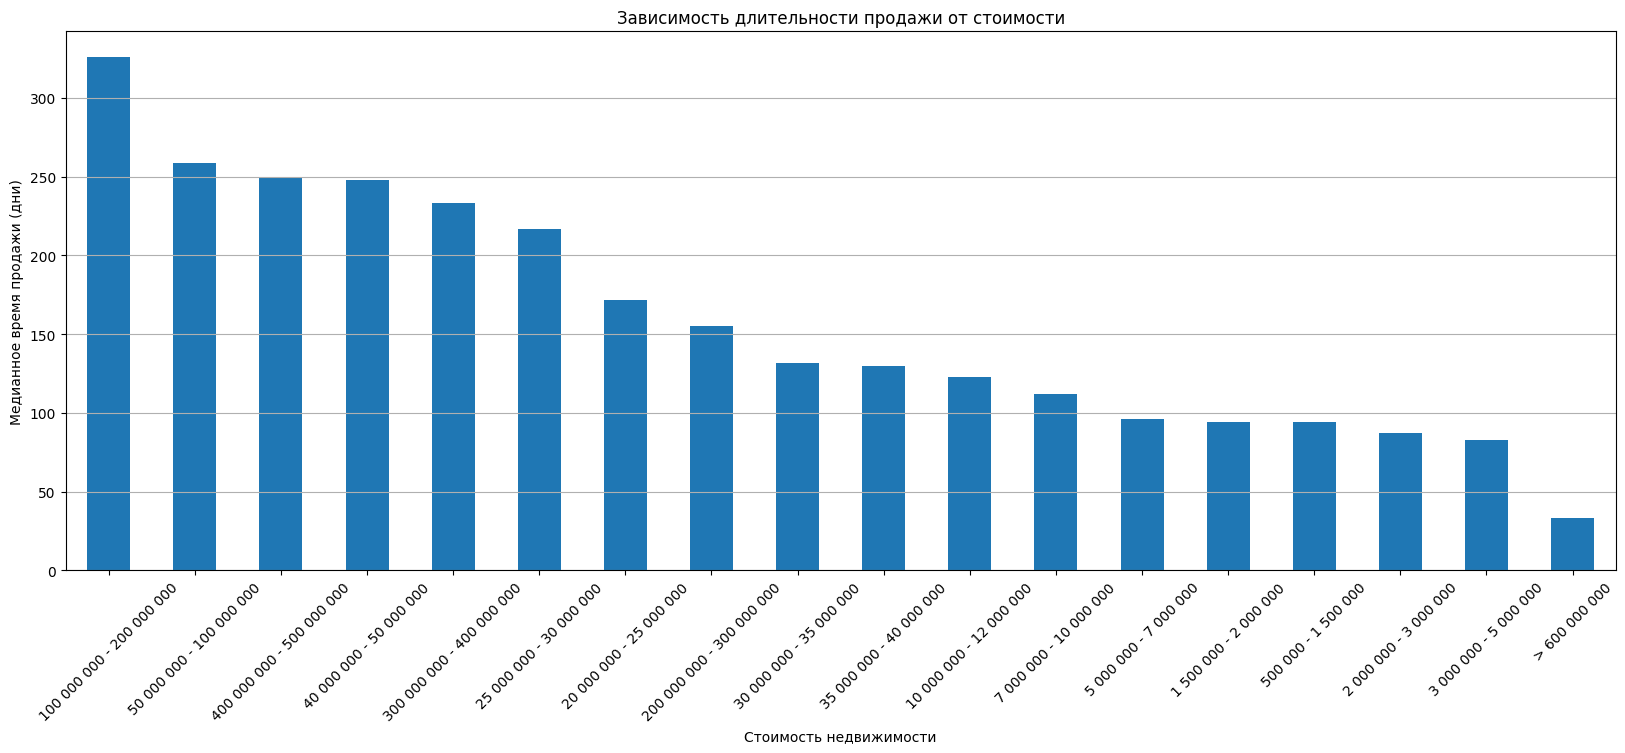

In [127]:
# Построение графика
plt.figure(figsize=(20, 7))  # Установка размера графика
days_exposition_median_price['median'].plot(kind='bar')  # Построение столбчатой диаграммы для медианного времени

# Установка заголовка и меток осей
plt.title('Зависимость длительности продажи от стоимости')
plt.xlabel('Стоимость недвижимости')
plt.ylabel('Медианное время продажи (дни)')
plt.xticks(rotation=45)  # Установка угла поворота меток по оси X
plt.grid(axis='y')  # Включение сетки по оси Y
plt.show()  # Отображение графика

Исходя из опыта, средний срок продажи жилой недвижимости со средней для нее ценой с усредненной сезонностью составдяе 6-7 мес = 200 дней для ровного счета - соответствует среднему здесь значению. Продажи квартир в данном датафрэйме по медиане 3,5-4 мес = 110 дней. Быстрее всего продаются дешевые квартиры - 2 000 000 -:- 10 000 000 р. Потому что они наиболее финансово доступные для населения и для применения программ господдрежки. Медленнее всего продаются квартиры 40 000 000 - 50 000 000 и 100 000 000 - 400 000 000 - это связано, на мой взгляд, с не сильной помощью госпрограмм на такое жилье (малы в сравнении с ценой) и необходимостью вывести/"достать" деньги из бизнеса/с продажи другого имущества в большинстве случаев. средне по длительности продаются квартиры 20 000 000 - 25 000 000 - для них доступны и госпрограммы, и необходимо реализовать другое имущество для покупки такой недвижимости - в данном ценовом сегменте и ниже в кармане у людей не завалялись данные суммы.

**Зависимость длительности продажи days_exposition от цены last_price**

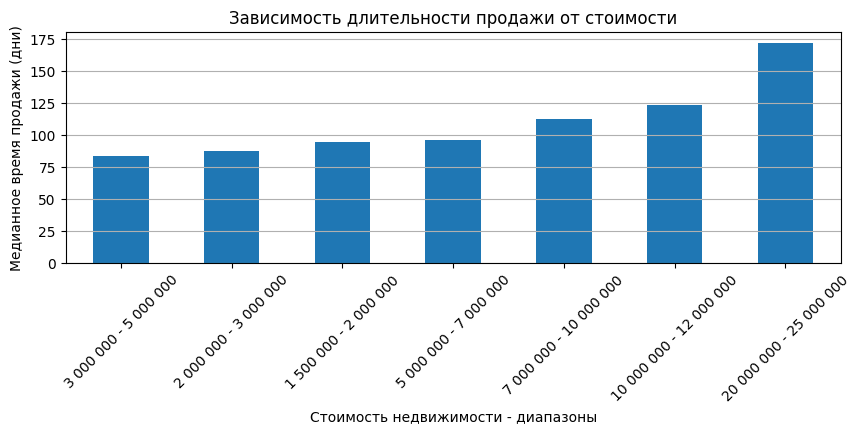

In [128]:
# Зависимость длительности продажи days_exposition от цены last_price

# Группировка по ценовым категориям и вычисление медианного времени продажи
days_exposition_median_price = data.groupby('def_last_price')['days_exposition'].agg(['median', 'count']).round(2)

# Фильтрация по количеству комнат
average_exposition_median_price_filtered = days_exposition_median_price[days_exposition_median_price.index.isin(['1 500 000 - 2 000 000', '2 000 000 - 3 000 000', '3 000 000 - 5 000 000', '5 000 000 - 7 000 000', '7 000 000 - 10 000 000', '10 000 000 - 12 000 000', '20 000 000 - 25 000 000'])]

# Сортировка по медианному значению
average_exposition_median_price_filtered = average_exposition_median_price_filtered.sort_values(by='median', ascending=True)

# Построение графика
average_exposition_median_price_filtered['median'].plot(
    kind='bar', 
    figsize=(10, 3)
)
# Установка заголовка и меток осей
plt.title('Зависимость длительности продажи от стоимости')
plt.xlabel('Стоимость недвижимости - диапазоны')
plt.ylabel('Медианное время продажи (дни)')
plt.xticks(rotation=45)  # Установка угла поворота меток по оси X
plt.grid(axis='y')  # Включение сетки по оси Y
plt.show()  # Отображение графика

Чем дороже квартира, тем дольше продажа. При ценах ниже рынка продажи также долгие.

**Зависимость длительности продажи days_exposition от удаленности от центра Санкт-Петербурга**

In [129]:
# Зависимость длительности продажи days_exposition от удаленности от центра Санкт-Петербурга
# Фильтрация данных 
data_spb = data[data['locality_name'] == 'г. Санкт-Петербург']

# Группировка по расстоянию до центра и вычисление средней стоимости
average_exposition_per_km = data_spb.groupby('cityCenters_nearest_km')['days_exposition'].agg(['median', 'count', 'mean', 'min', 'max']).round()
average_exposition_per_km = average_exposition_per_km.sort_values(by='cityCenters_nearest_km', ascending=True).round(2)
# Печать средней стоимости
print(average_exposition_per_km)

print('Медианное время продажи недвижимости составляет median', data['days_exposition'].median(), 'дней')
print('Среднее время продажи недвижимости составляет mean', data['days_exposition'].mean().round(), 'дней')

                        median  count   mean    min     max
cityCenters_nearest_km                                     
0.0                      178.0     19  321.0   11.0  1572.0
1.0                      169.0    164  275.0    3.0  1349.0
2.0                      143.0    255  247.0    3.0  1477.0
3.0                      119.0    275  233.0    3.0  1430.0
4.0                      151.0    569  266.0    3.0  1395.0
5.0                      161.0    772  274.0    3.0  1512.0
6.0                      119.0    519  217.0    3.0  1375.0
7.0                      135.0    347  204.0    3.0  1312.0
8.0                       98.0    517  202.0    3.0  1417.0
9.0                       90.0    515  178.0    2.0  1391.0
10.0                      93.0    631  171.0    2.0  1434.0
11.0                      88.0   1030  182.0    3.0  1513.0
12.0                      87.0   1403  157.0    2.0  1341.0
13.0                      87.0   1301  157.0    3.0  1257.0
14.0                      85.0   1117  1

<Axes: xlabel='cityCenters_nearest_km'>

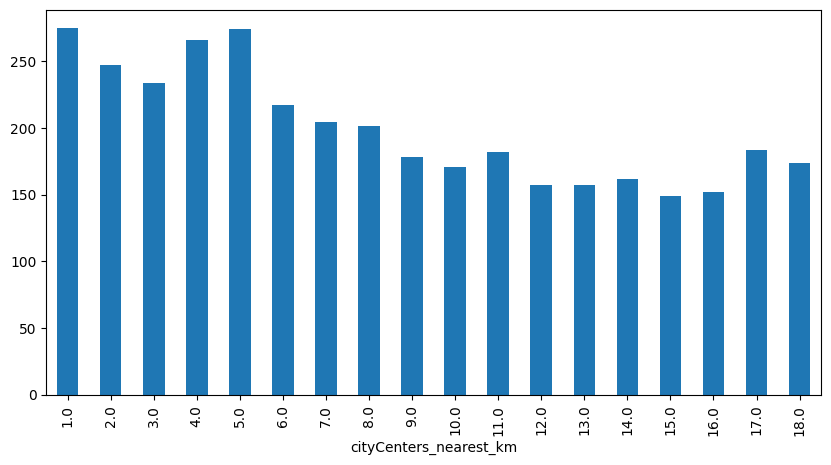

In [130]:
# Отфильтруем часть расстояний, потому что они редко встречаются (count)

average_exposition_per_km_filtered = average_exposition_per_km[average_exposition_per_km.index.isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18])]

average_exposition_per_km__ = data[data['cityCenters_nearest_km'].isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18])].groupby('cityCenters_nearest_km')['days_exposition'].agg('mean')

average_exposition_per_km__.plot(
    y='median', 
    kind='bar', 
    figsize=(10, 5)
)

Наблюдается зависимость длительности продажи от расстояния до центра С-П. Чем дальше - тем быстрее. График идет синусоидой с угасающей амплитудой, в связи с влиянием других параметров на длительномстьт продажи - инфраструктура и прочее.

**Зависимость длительности продажи days_exposition от количества комнат**

In [131]:
# Зависимость длительности продажи days_exposition от количества комнат
# Группировка по количеству комнат и вычисление статистик
average_exposition_rooms = data.groupby('rooms')['days_exposition'].agg(['median', 'count']).round(2)

# Сортировка по медианному значению
average_exposition_rooms = average_exposition_rooms.sort_values(by='median', ascending=False)

# Печать средней стоимости
print(average_exposition_rooms)

print('Медианное время продажи недвижимости составляет median', data['days_exposition'].median(), 'дней')
print('Среднее время продажи недвижимости составляет mean', data['days_exposition'].mean().round(), 'дней')

       median  count
rooms               
16     1365.0      1
11      813.0      1
9       469.5      4
14      256.5      2
8       249.0     11
6       204.0     75
5       185.5    250
4       155.0    922
7       138.0     37
3       114.0   4697
19      114.0      1
12      106.0      1
2        91.0   6678
1        81.0   7131
0        49.0    181
10       44.0      2
15       14.0      1
Медианное время продажи недвижимости составляет median 95.0 дней
Среднее время продажи недвижимости составляет mean 181.0 дней


<Axes: xlabel='rooms'>

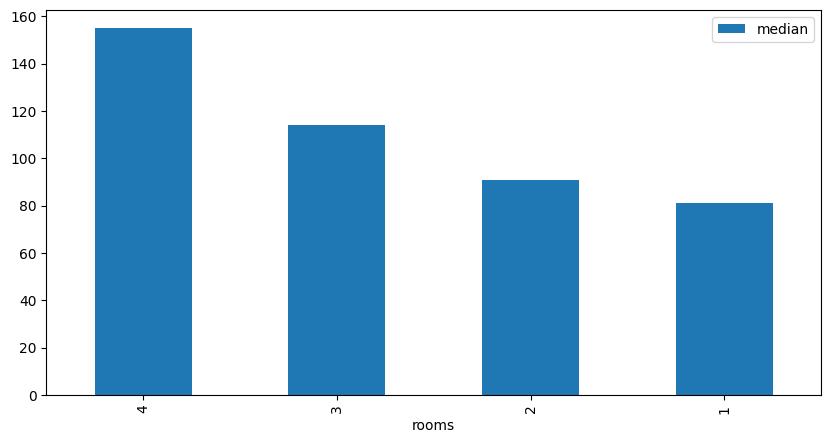

In [132]:
# Отфильтруем 1, 2, 3, 4, потому что остальные редко встречаются
average_exposition_rooms_filtered = average_exposition_rooms[average_exposition_rooms.index.isin([1, 2, 3, 4])]

average_debt = data[data['rooms'].isin([1, 2, 3, 4])].groupby('rooms')['days_exposition'].agg('mean')
average_exposition_rooms_filtered.plot(
    y='median', 
    kind='bar', 
    figsize=(10, 5)
)

Наблюдается четкая зависимость длительности продажи недвижимсоти от количества комнат. Чем меньше комнат, тем быстрее продастся недвижимость

In [133]:
# Зависимость длительности продажи days_exposition от типа недвижимости is_apartment
average_exposition_is_apartment = data.groupby('is_apartment')['days_exposition'].agg(['median', 'count']).round(2)
print(average_exposition_is_apartment)

              median  count
is_apartment               
0              131.0   2403
1               92.0  17592


Наблюдается четкая зависимость между продажей квартир и аппартаментов. Квартир продается и больше по количеству, и быстрее.

**Краткие выводы по длительности продаж:**

Наблюдается зависимость времени продажи недвижимости от населенного пункта. Чем дальше от столицы области находится населенный пункт, также чем больше отличается от города, тем дольше идут продажи.

Чем дороже квартира, тем дольше продажа. При ценах ниже рынка продажи также долгие.

Наблюдается зависимость длительности продажи от расстояния до центра С-П. Чем дальше - тем быстрее. График идет синусоидой с угасающей амплитудой, в связи с влиянием других параметров на длительномстьт продажи - инфраструктура и прочее.

Медианное время продажи недвижимости составляет median 95.0 дней
Среднее время продажи недвижимости составляет mean 181.0 дней

Обычно продажа недвижимости занимает 95 дней.

Продажи длительностью 44 дня и меньше можно считать быстрыми, а длительностью от 232 дней - необычно долгими.

Наблюдается четкая зависимость длительности продажи недвижимсоти от количества комнат. Чем меньше комнат, тем быстрее продастся недвижимость.

**Зависимость цены от общей площади**

In [134]:
# Зависимость цены от общей площади
def def_total_area(total_area):
    try:
        if 0 <= total_area <= 18.00:
            return '18-28 m2'
        elif 18.01 <= total_area <= 28.00:
            return '18-28 m2'
        elif 28.01 <= total_area <= 35.00:
            return '28-35 m2'
        elif 35.01 <= total_area <= 45.00:
            return '35-45 m2'
        elif 45.01 <= total_areae <= 50.00:
            return '45-50 m2'
        elif 50.01 <= total_area <= 55.00:
            return '50-55 m2'
        elif 55.01 <= total_area <= 60.00:
            return '55-60 m2'
        elif 60.01 <= total_area <= 65.00:
            return '60-65 m2'
        elif 65.01 <= total_area <= 70.00:
            return '65-70 m2'
        elif 70.01 <= total_area <= 75.00:
            return '70-75 m2'
        elif 75.01 <= total_area <= 80.00:
            return '75-80 m2'
        elif 80.01 <= total_area <= 90.00:
            return '80-90 m2'
        elif 90.01 <= total_area <= 100.00:
            return '90-100 m2'
        elif 100.01 <= total_area <= 120.00:
            return '100-120 m2'
        elif 120.01 <= total_area <= 150.00:
            return '120-150 m2'
        elif 150.01 <= total_area <= 200.00:
            return '150-200 m2'
        elif 200.01 <= total_area <= 300.00:
            return '200-300 m2'
        elif 300.01 <= total_area <= 400.00:
            return '300-400 m2'
        elif 400.01 <= total_area <= 500.00:
            return '400-500'
        elif 500.01 <= total_area <= 600.00:
            return '500-600'
        elif 600.01 <= total_area <= 700.00:
            return '600-700'
        elif 700.01 <= total_area <= 800.00:
            return '700-800'
        elif total_area >= 800.01:
            return '>= 800.01'
    except:
        pass
data['def_total_area'] = data['total_area'].apply(def_total_area)
print(data.head(5))

   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0           2019-03-07      3   
1             7   3350000.0        40.0           2018-12-04      1   
2            10   5196000.0        56.0           2015-08-20      2   
3             0  64900000.0       159.0           2015-07-24      3   
4             2  10000000.0       100.0           2018-06-19      2   

   ceiling_height  floors_total  living_area  floor is_apartment  ...  \
0            2.70          16.0         51.0      8            1  ...   
1            2.65          11.0         18.6      1            1  ...   
2            2.65           5.0         34.3      4            1  ...   
3            2.65          14.0          NaN      9            1  ...   
4            3.03          14.0         32.0     13            1  ...   

   days_exposition  m_2_price  floor_type  day_week_exposition  \
0              NaN  120370.37  НЕТ ДАННЫХ                    3   
1 

In [135]:
# Группировка по общей площади и общей стоимости
averag = data_spb.groupby('total_area')['last_price'].agg(['median', 'count', 'mean', 'min', 'max']).round()
averag_ = averag.sort_values(by='total_area', ascending=True).round(2)
# Печать средней стоимости
print(averag_)

                 median  count         mean          min          max
total_area                                                           
12.0          2400000.0      1    2400000.0    2400000.0    2400000.0
13.0          1768000.0      4    2184000.0    1400000.0    3800000.0
15.0          2000000.0      2    2000000.0    1550000.0    2450000.0
16.0          2100000.0      1    2100000.0    2100000.0    2100000.0
17.0          2050000.0      3    2395667.0    1737000.0    3400000.0
...                 ...    ...          ...          ...          ...
517.0        50000000.0      1   50000000.0   50000000.0   50000000.0
590.0        65000000.0      1   65000000.0   65000000.0   65000000.0
618.0       300000000.0      1  300000000.0  300000000.0  300000000.0
631.0       140000000.0      2  140000000.0  140000000.0  140000000.0
900.0       420000000.0      1  420000000.0  420000000.0  420000000.0

[308 rows x 5 columns]


In [136]:
# Фильтрация данных по общей площади цене для наглядности
filtered_data = data[(data['total_area'] >= 0) & (data['total_area'] <= 150) & (data['last_price'] >= 0) & (data['last_price'] <= 20000000)]


In [137]:
# filtered_data.plot(x='total_area', y='last_price', kind='hexbin', gridsize=20, figsize=(8, 6), sharex=False, grid=True) 

Чем больше площадь, тем больше цена.

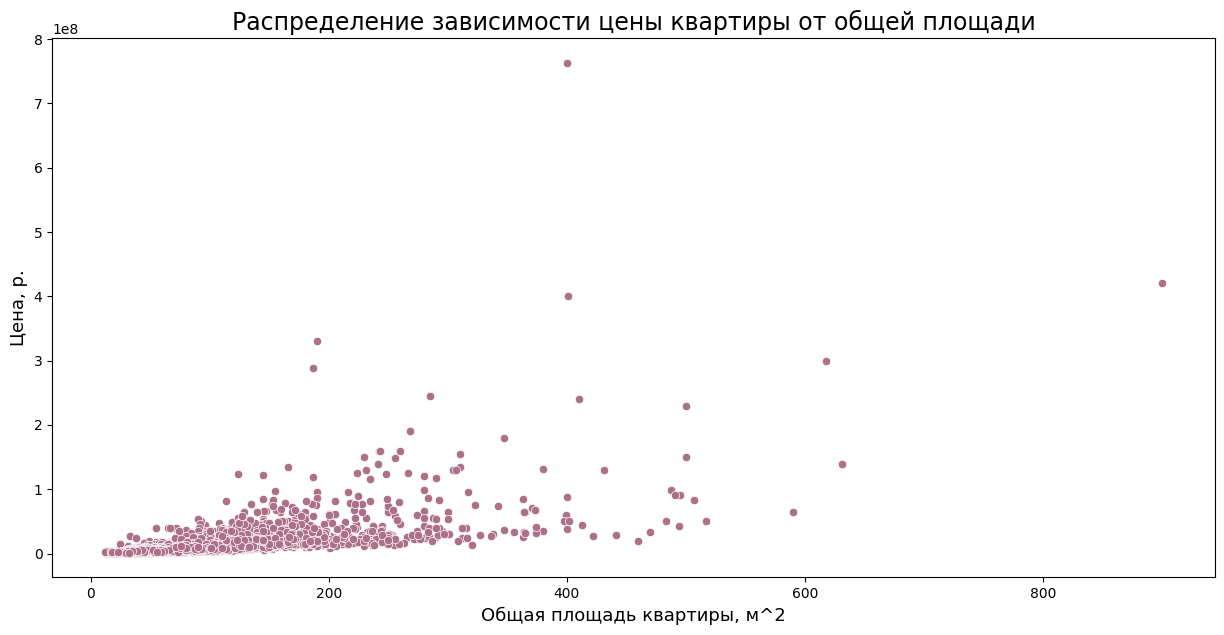

In [138]:
# График распределения зависимости цены квартиры от общей площади

plt.figure(figsize=(15, 7))

sns.scatterplot(data=data,  x='total_area', y='last_price', color='#AC7088')

plt.title('Распределение зависимости цены квартиры от общей площади', size=17)
plt.xlabel('Общая площадь квартиры, м^2', size=13)
plt.ylabel('Цена, р.', size=13)

plt.show()

**Зависимость цены от жилой площади**

In [139]:
# Зависимость цены от жилой площади
# Группировка по жилой площади и общей стоимости
average_living_area_last_price = data_spb.groupby('living_area')['last_price'].agg(['median', 'count', 'mean', 'min', 'max']).round()
average_living_area_last_price = average_living_area_last_price.sort_values(by='living_area', ascending=True).round(2)
# Печать средней стоимости
print(average_living_area_last_price)

                  median  count         mean          min          max
living_area                                                           
8.0            6850000.0      2    6850000.0    4800000.0    8900000.0
8.3            4000000.0      1    4000000.0    4000000.0    4000000.0
8.5            4100000.0      1    4100000.0    4100000.0    4100000.0
8.9            5300000.0      1    5300000.0    5300000.0    5300000.0
9.0            4600000.0      9    4926667.0    3300000.0    8100000.0
...                  ...    ...          ...          ...          ...
322.3        140000000.0      1  140000000.0  140000000.0  140000000.0
332.0         50000000.0      1   50000000.0   50000000.0   50000000.0
347.5         91500000.0      1   91500000.0   91500000.0   91500000.0
409.0         65000000.0      1   65000000.0   65000000.0   65000000.0
409.7        420000000.0      1  420000000.0  420000000.0  420000000.0

[1467 rows x 5 columns]


In [140]:
# Фильтрация данных по общей площади и цене для наглядности
filtered_data_average_living_area_last_price = data[(data['living_area'] >= 0) & (data['living_area'] <= 100) & (data['last_price'] >= 0) & (data['last_price'] <= 20000000)]


In [141]:
# filtered_data_average_living_area_last_price.plot(x='living_area', y='last_price', kind='hexbin', gridsize=20, figsize=(8, 6), sharex=False, grid=True) 

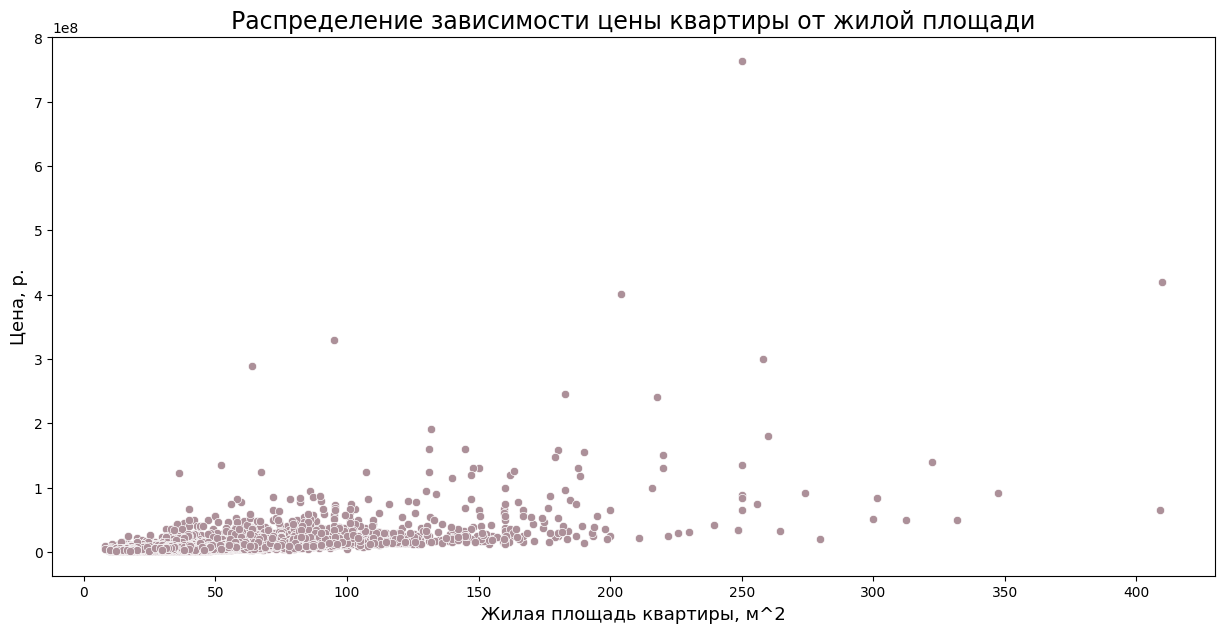

In [142]:
# График зависимости цены от жилой площади


plt.figure(figsize=(15, 7))

sns.scatterplot(data=data,  x='living_area', y='last_price', color='#AC9099')

plt.title('Распределение зависимости цены квартиры от жилой площади', size=17)
plt.xlabel('Жилая площадь квартиры, м^2', size=13)
plt.ylabel('Цена, р.', size=13)

plt.show()

Очевидно - чем больше жилая площадь, тем больше цена. 

**Зависимость цены от площади кухни**

In [143]:
# Зависимость цены от площади кухни
# Группировка по площади кухни и общей стоимости
average_kitchen_area_last_price = data_spb.groupby('kitchen_area')['last_price'].agg(['median', 'count', 'mean', 'min', 'max']).round()
average_kitchen_area_last_price = average_kitchen_area_last_price.sort_values(by='kitchen_area', ascending=True).round(2)
# Печать средней стоимости
print(average_kitchen_area_last_price)

                   median  count         mean          min          max
kitchen_area                                                           
5.00            4000000.0    138    4526558.0    2550000.0   22190000.0
5.06            3400000.0      1    3400000.0    3400000.0    3400000.0
5.10            3950000.0     29    4003241.0    2590000.0    5700000.0
5.20            3995000.0     58    4129397.0    2200000.0    6700000.0
5.21            3800000.0      1    3800000.0    3800000.0    3800000.0
...                   ...    ...          ...          ...          ...
93.20          82400000.0      1   82400000.0   82400000.0   82400000.0
100.00         65000000.0      1   65000000.0   65000000.0   65000000.0
100.70         12500000.0      1   12500000.0   12500000.0   12500000.0
107.00         85000000.0      1   85000000.0   85000000.0   85000000.0
112.00        420000000.0      1  420000000.0  420000000.0  420000000.0

[770 rows x 5 columns]


In [144]:
# Фильтрация данных для наглядности
# Фильтрация данных по общей площади цене для наглядности
filtered_data_average_kitchen_area_last_price = data[(data['kitchen_area'] >= 0) & (data['kitchen_area'] <= 40) & (data['last_price'] >= 0) & (data['last_price'] <= 20000000)]

In [145]:
# filtered_data_average_kitchen_area_last_price.plot(x='kitchen_area', y='last_price', kind='hexbin', gridsize=20, figsize=(10, 6), sharex=False, grid=True) 

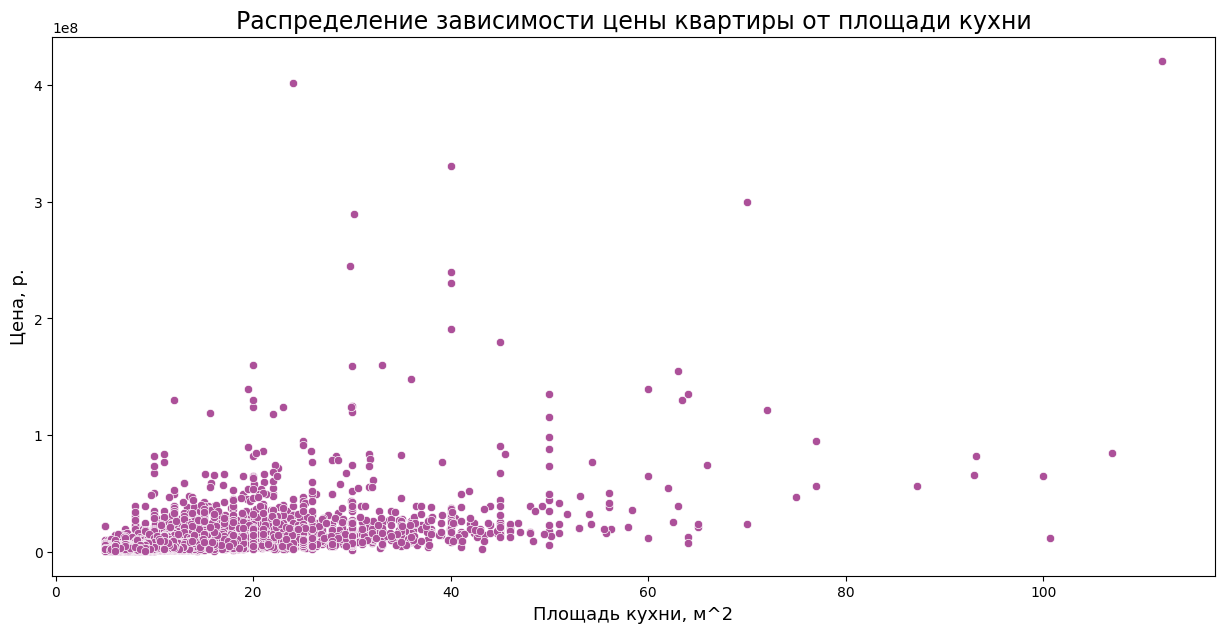

In [146]:
# График зависимости цены от жилой площади


plt.figure(figsize=(15, 7))

sns.scatterplot(data=data,  x='kitchen_area', y='last_price', color='#AC5099')

plt.title('Распределение зависимости цены квартиры от площади кухни', size=17)
plt.xlabel('Площадь кухни, м^2', size=13)
plt.ylabel('Цена, р.', size=13)

plt.show()

Чем больше площадь кухни, тем больше цена.

**Зависимость цены от количества комнат**

In [147]:
# Зависимость цены от количества комнат
# Группировка по 'rooms' и агрегация
grouped_data_rooms = data.groupby('last_price')['rooms'].agg(
    count='count',
    last_value_rooms=lambda x: x.iloc[-1]
)
# Сортировка по убыванию по последнему значению
sorted_data_rooms = grouped_data_rooms.sort_values(by='last_value_rooms', ascending=False)

# Печать отсортированных результатов
print(sorted_data_rooms.head(10))
print(sorted_data_rooms.tail(10))

             count  last_value_rooms
last_price                          
32250000.0       1                19
28500000.0       1                16
28659000.0       1                14
420000000.0      1                12
88000000.0       1                 9
22250000.0       1                 9
24000000.0       9                 9
49968900.0       1                 9
22190000.0       2                 8
16100000.0       1                 8
            count  last_value_rooms
last_price                         
2176000.0       1                 0
2420000.0       1                 0
2460000.0       4                 0
2340000.0       2                 0
2952500.0       1                 0
2948000.0       2                 0
3090000.0      18                 0
3255000.0       3                 0
4280000.0      11                 0
1450000.0      33                 0


Восновном продаются 2-х и 3-хкомнатные квартиры. Есть квартиры и с 16, 12 компатами, но и цены у них соответствующие. Не удаляем ничего.

In [148]:
# Группировка и агрегация, фильтрация по комнатам
average_rooms_price = data[data['rooms'].isin([1, 2, 3, 4])].groupby('rooms')['last_price'].agg(['mean', 'median']).reset_index()

# Фильтрация по ценовым категориям
average_rooms_price = average_rooms_price[average_rooms_price['rooms'].isin([1, 2, 3, 4])]

# Сортировка по медианному значению
average_rooms_price = average_rooms_price.sort_values(by='median', ascending=True)

In [149]:
# Построение графика
# average_rooms_price.plot(x='median', y='rooms', kind='hexbin', gridsize=20, figsize=(8, 6), sharex=False, grid=True) 

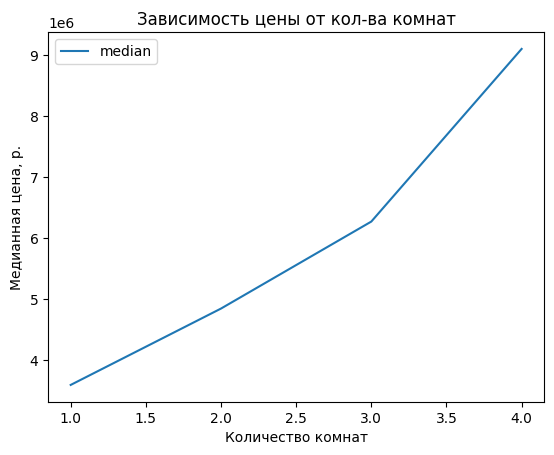

In [150]:
# Зависимость цены недвижимости от количествава комнат
average_rooms_price.groupby('rooms')['median'].agg(['median']).plot()
plt.title('Зависимость цены от кол-ва комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Медианная цена, р.')
plt.show()

Чем больше комнат в квартире, тем больше цена на нее.

**Зависимость цены от типа этажа, на котором расположена квартира (первый, последний, другой)**

In [151]:
# Зависимость цены от типа этажа, на котором расположена квартира (первый, последний, другой)
# Группировка
average_last_price_floor_type = data.groupby('floor_type')['last_price'].agg(['median', 'count']).round(2)

# Сортировка по медианному значению
average_last_price_floor_type = average_last_price_floor_type.sort_values(by='median', ascending=False)

# Печать медианной стоимости
print('медианная стоимость и количество')
print(average_last_price_floor_type)

медианная стоимость и количество
               median  count
floor_type                  
НЕТ ДАННЫХ  4899000.0  17159
последний   4490000.0   3159
первый      4000000.0   2754


<Axes: xlabel='floor_type'>

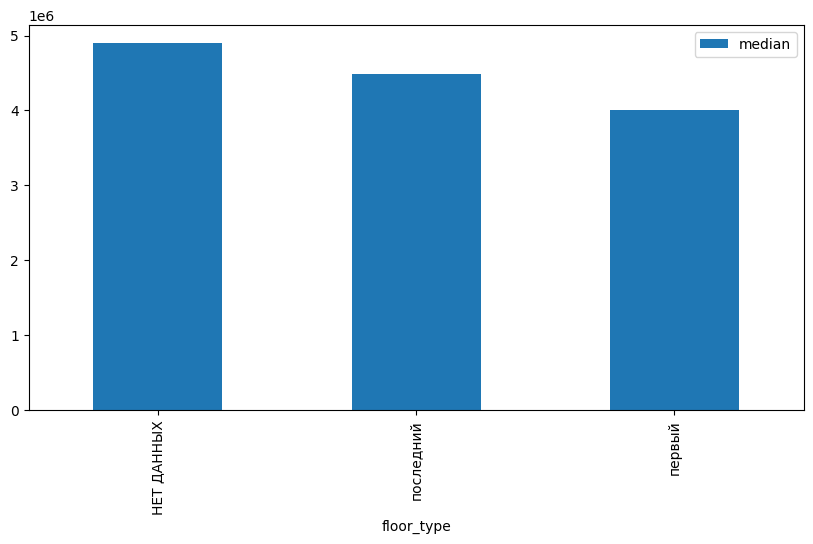

In [152]:
average_last_price_floor_type.plot(
    y='median', 
    kind='bar', 
    figsize=(10, 5)
)

Самый дешевый - 1й этаж, дороже - последний этаж, самые дорогие - остальные этажи.

**Зависимость цены last_price от даты размещения (день недели, месяц, год) first_day_exposition**

In [153]:
# Зависимость цены last_price от даты размещения (день недели, месяц, год) first_day_exposition
# Группировка и агрегация
grouped_last_price_first_day = data.groupby('first_day_exposition')['last_price'].agg(['median', 'count', 'mean']).reset_index()

# Сортировка по убыванию медианной цены
grouped_last_price_first_day_sorted = grouped_last_price_first_day.sort_values(by='count', ascending=False)

# Печать отсортированных результатов
print(grouped_last_price_first_day_sorted.head())
print(grouped_last_price_first_day_sorted.tail())

     first_day_exposition     median  count          mean
1035           2018-02-01  4600000.0    357  6.188414e+06
960            2017-11-10  4700000.0    239  6.672452e+06
932            2017-10-13  4100000.0    117  5.216277e+06
916            2017-09-27  5100000.0    110  7.170913e+06
1088           2018-03-26  3950000.0     95  6.224920e+06
    first_day_exposition      median  count        mean
542           2016-09-03   5350000.0      1   5350000.0
544           2016-09-05   3800000.0      1   3800000.0
42            2015-01-29  10018000.0      1  10018000.0
44            2015-02-03   4400000.0      1   4400000.0
46            2015-02-06  17900000.0      1  17900000.0


/var/folders/nl/qb3_y6cj3lxgsxxz059t4t740000gn/T/ipykernel_77774/260535000.py:4: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  plt.hexbin(grouped_last_price_first_day_sorted['first_day_exposition'].view('int64'),


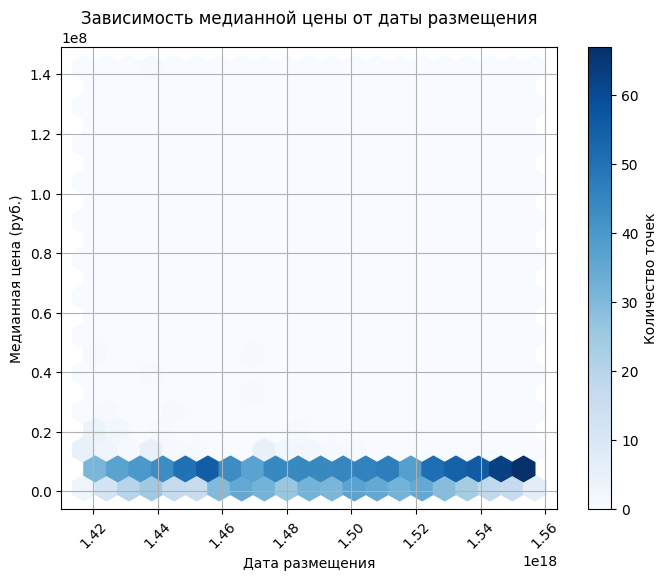

In [154]:
# Построение графика 
# Зависимость стоимости от даты размещения объявления о продаже
plt.figure(figsize=(8, 6))
plt.hexbin(grouped_last_price_first_day_sorted['first_day_exposition'].view('int64'), 
           grouped_last_price_first_day_sorted['median'], 
           gridsize=20, 
           cmap='Blues')
plt.colorbar(label='Количество точек')
plt.title('Зависимость медианной цены от даты размещения')
plt.xlabel('Дата размещения')
plt.ylabel('Медианная цена (руб.)')
plt.xticks(rotation=45)  # Установка меток по оси X
plt.grid(True)
plt.show()

По выведенному графику лишь понятно, что есть сезонность. также - чем позже выставлена квартира, тем она дороже - это объясняется попросу повышением цен со временем. Исследуем зависимость цены от дня недели выставления недвижимости, месяца, года.

**Зависимость цены last_price от года размещения объявления**

In [155]:
# Зависимость цены от года размещения объявления
# Группировка и агрегация
grouped_last_price_first_year = data.groupby('year_exposition')['last_price'].agg(['median', 'count', 'mean']).reset_index()

# Сортировка по возрастанию медианной цены
grouped_last_price_first_year_sorted = grouped_last_price_first_year.sort_values(by='count', ascending=True)


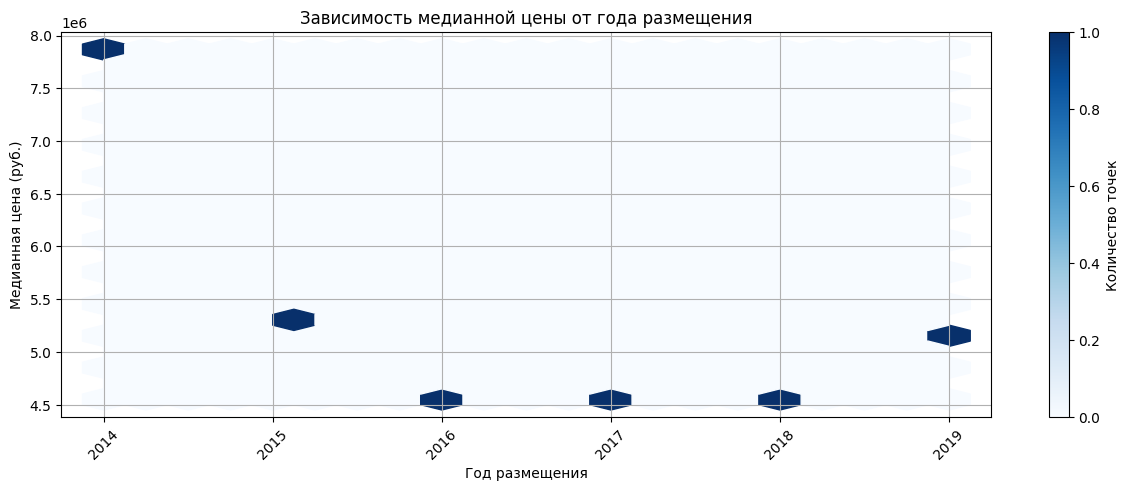

In [156]:
# Построение графика
plt.figure(figsize=(15, 5))
plt.hexbin(grouped_last_price_first_year_sorted['year_exposition'], 
           grouped_last_price_first_year_sorted['median'], 
           gridsize=20, 
           cmap='Blues')
plt.colorbar(label='Количество точек')
plt.title('Зависимость медианной цены от года размещения')
plt.xlabel('Год размещения')
plt.ylabel('Медианная цена (руб.)')
plt.xticks(rotation=45)  # Установка меток по оси X
plt.grid(True)
plt.show()

В 2014 г. был скачок доллара и политические изменения в мире и, в частности, в РФ. В связи с этим в конце 2014 года цены на все подскачили. И все успокоилось за пару лет. Дальше из года в год цены поднимались, в т.ч. - на недвижимость.

Т.о. зависимость цен на квартиры от года размещения есть. С каждым годом цены на недвижимость растут. При глобальных изменениях политического и экономического характера цены скачкообразно поднимаются.

**Зависимость цены last_price от месяца размещения объявления**

In [157]:
# Зависимость цены от месяца размещения объявления
grouped_last_price_first_month = data.groupby('month_exposition')['last_price'].agg(['median', 'count', 'mean']).reset_index()

# Сортировка по возрастанию медианной цены
grouped_last_price_first_month_sorted = grouped_last_price_first_month.sort_values(by='median', ascending=True)

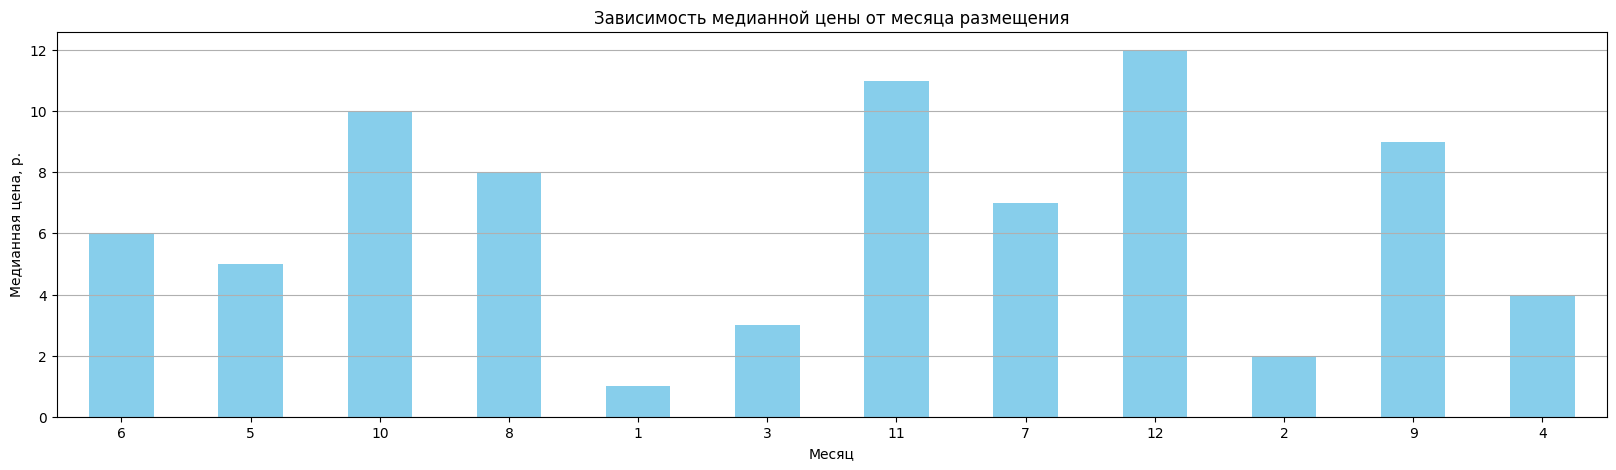

In [158]:
# Зависимость медианной цены от месяца размещения
plt.figure(figsize=(20, 5))  # Установка размера графика
grouped_last_price_first_month_sorted['month_exposition'].plot(kind='bar', color='skyblue')

# Установка заголовка и меток осей
plt.title('Зависимость медианной цены от месяца размещения')
plt.xlabel('Месяц')
plt.ylabel('Медианная цена, р.')
plt.xticks(ticks=range(len(grouped_last_price_first_month_sorted)), labels=grouped_last_price_first_month_sorted['month_exposition'], rotation=0)  # Установка меток по оси X
plt.grid(axis='y')  # Включение сетки по оси Y
plt.show()  # Отображение графика


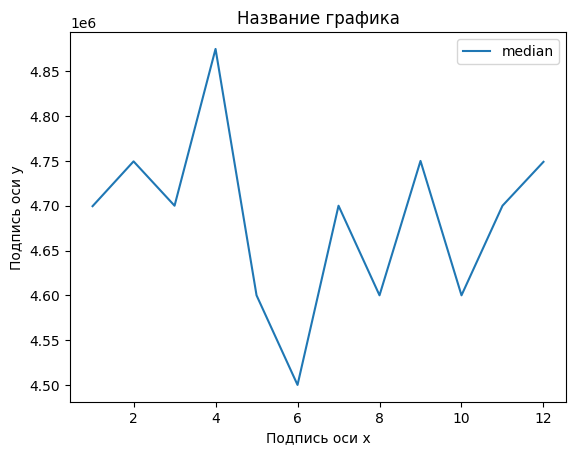

In [159]:
# код ревьюера
data.groupby('month_exposition')['last_price'].agg(['median']).plot()
plt.title('Название графика')
plt.xlabel('Подпись оси х')
plt.ylabel('Подпись оси у')
plt.show()

Зависимость цены квартир от месяца размещения объявления есть. Сезоны с дорогими квартирами - Новый год и месяцы рядом с ним - ноябрь - январь. Также - весна. В начале лета цены падают в связи со школьными и институтскими сдачами экзаменов, поступлениями, началом отпусков и активного дачного сезона. Далее летом цена растет, а в снтябре и до октября падает в связи с началом учебного года, подготовкой к сдаче и сдачей проектов на работах. 

**Зависимость цены last_price от дня недели размещения объявления**

In [160]:
# Зависимость цены от дня недели размещения объявления
grouped_last_price_first_day_day = data.groupby('day_week_exposition')['last_price'].agg(['median', 'count', 'mean']).reset_index()

# Сортировка по возрастанию медианной цены
grouped_last_price_first_day_day_sorted = grouped_last_price_first_day_day.sort_values(by='count', ascending=True)
print(grouped_last_price_first_day_day_sorted.head(5))
print(grouped_last_price_first_day_day_sorted.tail(5))

   day_week_exposition     median  count          mean
6                    6  4600000.0   1650  6.372859e+06
5                    5  4650000.0   1866  7.187559e+06
0                    0  4700000.0   3537  6.604573e+06
2                    2  4800000.0   3868  6.752839e+06
4                    4  4630000.0   3893  6.482514e+06
   day_week_exposition     median  count          mean
0                    0  4700000.0   3537  6.604573e+06
2                    2  4800000.0   3868  6.752839e+06
4                    4  4630000.0   3893  6.482514e+06
1                    1  4800000.0   4087  6.482607e+06
3                    3  4700000.0   4171  6.849449e+06


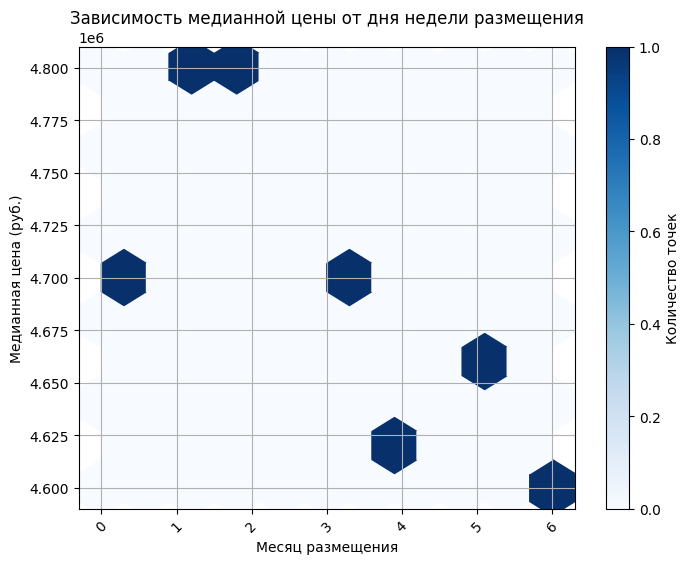

In [161]:
# Построение графика
plt.figure(figsize=(8, 6))
plt.hexbin(grouped_last_price_first_day_day_sorted['day_week_exposition'], 
           grouped_last_price_first_day_day_sorted['median'], 
           gridsize=10, 
           cmap='Blues')
plt.colorbar(label='Количество точек')
plt.title('Зависимость медианной цены от дня недели размещения')
plt.xlabel('Месяц размещения')
plt.ylabel('Медианная цена (руб.)')
plt.xticks(rotation=45)  # Установка меток по оси X
plt.grid(True)
plt.show()

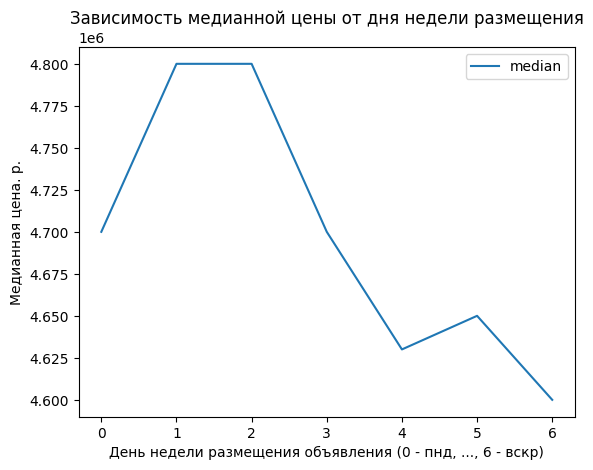

In [162]:
# График Зависимость медианной цены от дня недели размещения
data.groupby('day_week_exposition')['last_price'].agg(['median']).plot()
plt.title('Зависимость медианной цены от дня недели размещения')
plt.xlabel('День недели размещения объявления (0 - пнд, ..., 6 - вскр)')
plt.ylabel('Медианная цена. р.')
plt.show()

Судя по графику, зависимость цены от дня рахзмещения есть - в понедельник-среду цена выше, чем в другие дни. Но логической взаимосвязи я не вижу. Поэтому сделаю вывод об отсутствии зависимости цены от дня недели размещения.

In [163]:
# Зависимость цены от типа недвижимости is_apartment
average_price_is_apartment = data.groupby('is_apartment')['last_price'].agg(['median', 'count']).round(2)
print(average_price_is_apartment)

                 median  count
is_apartment                  
0             4770338.0   2659
1             4700000.0  20413


Цена квартир меньше, но сравнима с ценой аппартаментов.

Квартир продается их на рынке больше.

 **Вывод** по зависимости стоимости недвижимости от:
 
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - количество комнат;
        - тип этажа, на котором расположена квартира (первый, последний, другой);
        - дата размещения (день недели, месяц, год),
        - типа недвижимости (квартира или не квартира)
        
Чем больше общая площадь, тем больше стоимость недвижимости.

Чем больше жилая площадь, тем больше стоимость недвижимости.

Чем больше площадь кухни, тем больше стоимость недвижимости.

Чем больше количество комнат, тем больше стоимость недвижимости.

Самый дешевый - 1й этаж, дороже - последний этаж, самые дорогие - остальные этажи.

Чем позже размещено объявление о продаже недвижимости, тем дороже цена квартиры - всилу общего повышения цен со временем.

При политических и/или экономических резких изменениях резко увеличивается и стоимость квартир.

Стоимость квартир зависит и от месяца размещения - сезонности. Высокий сезон - новогодний (11,12,01 месяцы), весенний - апрель, летний - июль, август. Когда люди освобождаются полностью или частично от бытовых дел (дачи, отпуска, сдача учебных экзаменов и тд) и от рабочих дел - когда люди сдали рабочие проекты/отчеты перед госорганами и тд.

Стоимость недвижимости зависит от ее типа. Цена квартир меньше, но сравнима с ценой аппартаментов. Квартир продается на рынке больше.


**Расчет средней цены одного кв м в 10 населённых пунктах с наибольшим числом объявлений**.
Выделим **населённые пункты** с **самой высокой и низкой стоимостью квадратного метра**.

In [164]:
# 10 населенных пунктов с наибольшим числом объявлений (locality_name ---- count)
data_10_locality_name_m_2 = data.groupby('locality_name')['m_2_price'].agg(['count', 'mean', 'min', 'median', 'max'])
data_10_locality_name_m_2 = data_10_locality_name_m_2.sort_values(by='count', ascending=False).round(2)
print(data_10_locality_name_m_2.head(10))

                    count       mean       min     median         max
locality_name                                                        
г. Санкт-Петербург  15651  115364.89  35384.62  105263.16  1907500.00
п. Мурино             585   86608.83  50000.00   86666.67   140312.50
д. Кудрово            472   95879.32  54336.96   96190.14   162025.32
п. Шушары             438   78906.36  47766.67   77111.54   147826.09
Всеволожск            398   68985.24  31400.00   65811.40   642444.74
Пушкин                366  103670.48  59836.07  100000.00   256521.74
Колпино               338   75735.59  48214.29   74861.11   125000.00
п. Парголово          327   90675.63  39303.48   92222.22   141891.89
Гатчина               298   69838.18  38775.51   68561.58   146315.79
г. Выборг             230   59209.82  33547.95   58972.48   107473.12


In [165]:
# населённые пункты с самой высокой и низкой стоимостью квадратного метра из предыдущих 10 нас. пунктов.
# смотрим locality_name ---- median
data_10_locality_name_m_2 = data_10_locality_name_m_2.sort_values(by='median', ascending=False).round(2)
print(data_10_locality_name_m_2.head(10))

                    count       mean       min     median         max
locality_name                                                        
г. Санкт-Петербург  15651  115364.89  35384.62  105263.16  1907500.00
Пушкин                366  103670.48  59836.07  100000.00   256521.74
д. Кудрово            472   95879.32  54336.96   96190.14   162025.32
п. Парголово          327   90675.63  39303.48   92222.22   141891.89
п. Мурино             585   86608.83  50000.00   86666.67   140312.50
Павловск               38   84482.88  53448.28   85410.20   161428.57
Петергоф              201   85259.84  51612.90   82812.50   228392.86
г. Кронштадт           92   80222.90  47169.81   81818.18   111470.59
п. Шушары             438   78906.36  47766.67   77111.54   147826.09
д. Новое Девяткино    144   76497.36  48658.54   74886.36   108684.21


Населенные пункты с самой высокой и низкой стоимостью квадратного метра из предыдущих 10 нас. пунктов. (locality_name ---- median).

В г. Санкт-Петербург - самая высокая стоимость 1 кв м (максимальная медианная) составляет 103 254 р.

В г. Ломоносов - самая низкая стоимость 1 кв м (минимальная медианная) составляет 72 700 р.

In [166]:
# населённые пункты с самой высокой и низкой стоимостью квадратного метра из всего датафрэйма
data_10_locality_name_m_2 = data_10_locality_name_m_2.sort_values(by='median', ascending=False).round(2)
print(data_10_locality_name_m_2.head(1))
print()
print()
print(data_10_locality_name_m_2.tail(1))

                    count       mean       min     median        max
locality_name                                                       
г. Санкт-Петербург  15651  115364.89  35384.62  105263.16  1907500.0


               count      mean      min    median       max
locality_name                                              
п. Плодовое        3  33383.84  30000.0  31818.18  38333.33


Населенные пункты с самой высокой и низкой стоимостью квадратного метра из всего датафрэйма. (locality_name ---- median).

В г. Санкт-Петербург - самая высокая стоимость 1 кв м (максимальная медианная) составляет 103 254 р.

В п. Плодовое - самая низкая стоимость 1 кв м (минимальная медианная) составляет 31 838 р.

_____________________________________________________________________________

Выделение **квартир в Санкт-Петербурге** с помощью столбца `locality_name` и вычисление их **средней стоимости** на разном **удалении от центра**»:

    -  учтён каждый километр расстояния, известны средние цены квартир в одном километре от центра, в двух и так далее;
    
    -  описано, как стоимость объекта зависит от расстояния до центра города;
    
    -  построен график изменения средней цены для каждого километра от центра Петербурга.
   

In [167]:
# Фильтрация данных для Санкт-Петербурга
data_spb = data[data['locality_name'] == 'г. Санкт-Петербург']

# Группировка по расстоянию до центра и вычисление средней стоимости
average_price_per_km = data_spb.groupby('cityCenters_nearest_km')['last_price'].agg(['median', 'count', 'mean', 'min', 'max']).round()
average_price_per_km = average_price_per_km.sort_values(by='cityCenters_nearest_km', ascending=True).round(2)
# Печать средней стоимости
print(average_price_per_km)

                            median  count        mean        min          max
cityCenters_nearest_km                                                       
0.0                     17900000.0     27  31449116.0  5300000.0  159000000.0
1.0                     11395000.0    192  21206721.0  2400000.0  330000000.0
2.0                     10150000.0    308  17863601.0  2100000.0  401300000.0
3.0                      8418000.0    349  11143563.0  2385000.0   88000000.0
4.0                      9300000.0    681  13392550.0  1686000.0  763000000.0
5.0                      9500000.0    913  14575468.0  1850000.0  300000000.0
6.0                      8900000.0    615  15297484.0  2600000.0  245000000.0
7.0                      7800000.0    419  14795260.0  2250000.0  135000000.0
8.0                      7450000.0    597   9957717.0  2190000.0  420000000.0
9.0                      5301000.0    591   6969760.0  2190000.0   39900000.0
10.0                     5050000.0    716   6519276.0  2400000.0

<Axes: xlabel='cityCenters_nearest_km'>

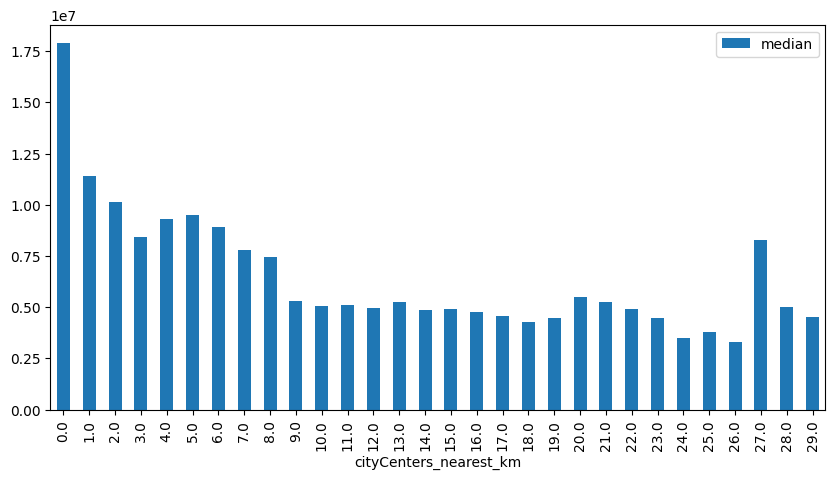

In [168]:
average_price_per_km.plot(
    y='median', 
    kind='bar', 
    figsize=(10, 5)
)

Цена недвижимости зависит от удаленности от центра города. Чем ближе к центру, тем дороже. Пиковое значение на 45 и 55 км от центра - думаю, это связано с единичными дорогими загородными резиденциями или расположением в больших городах Ленобласти.

cityCenters_nearest_km
0.0     175757.580
1.0     128679.655
2.0     123575.730
3.0     108695.650
4.0     118125.000
5.0     127777.780
6.0     132000.000
7.0     127173.910
8.0     123437.500
9.0     106250.000
10.0    107427.110
11.0    104065.040
12.0    104430.555
13.0    104687.500
14.0    102631.580
15.0    101630.410
16.0     98000.000
17.0     94665.180
18.0     95454.550
19.0     98372.090
20.0    103703.690
21.0     89724.735
22.0     89237.450
23.0     90909.090
24.0     86801.075
25.0     94814.395
26.0     90389.300
27.0    132115.710
28.0     79372.090
29.0     76612.905
Name: m_2_price, dtype: float64


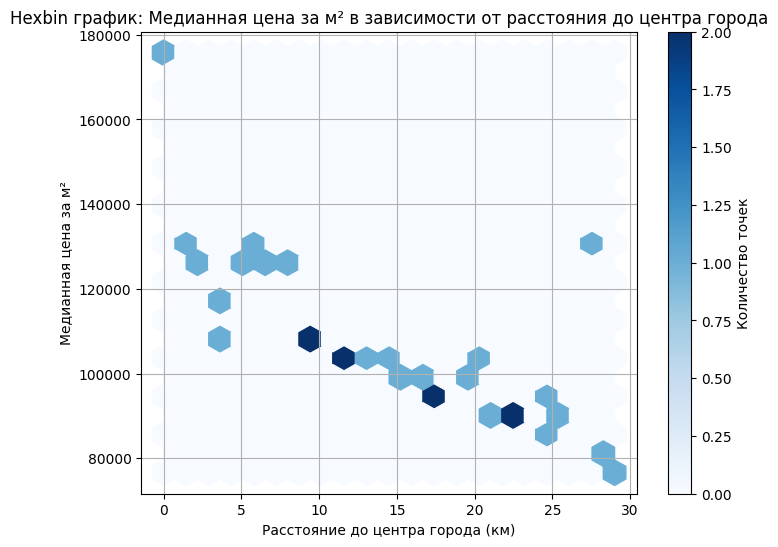

In [170]:
# Фильтрация данных для Санкт-Петербурга и группировка
data_S_P_km_m_2_price = data[data['locality_name'] == 'г. Санкт-Петербург'].groupby('cityCenters_nearest_km')['m_2_price'].agg('median')

# Печать медианных значений
print(data_S_P_km_m_2_price)

# Построение графика hexbin
plt.figure(figsize=(8, 6))
plt.hexbin(data_S_P_km_m_2_price.index, data_S_P_km_m_2_price.values, gridsize=20, cmap='Blues')
plt.colorbar(label='Количество точек')
plt.title('Hexbin график: Медианная цена за м² в зависимости от расстояния до центра города')
plt.xlabel('Расстояние до центра города (км)')
plt.ylabel('Медианная цена за м²')
plt.grid(True)
plt.show()

NameError: name 'median_price_by_distance' is not defined

<Figure size 1500x500 with 0 Axes>

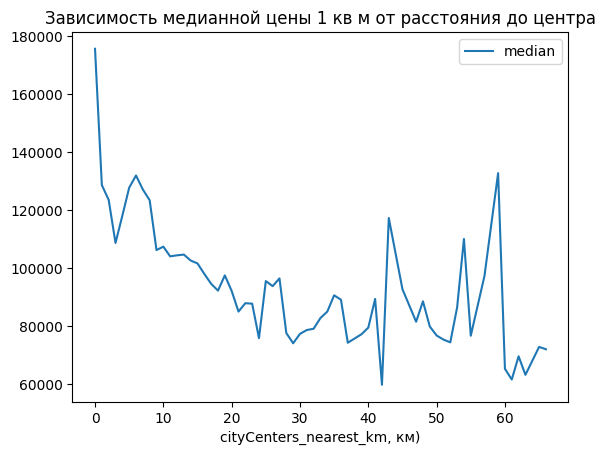

In [171]:
# Зависимость медианной цены 1 кв м от расстояния до центра
plt.figure(figsize=(15, 5))
data.groupby('cityCenters_nearest_km')['m_2_price'].agg(['median']).plot()
plt.title('Зависимость медианной цены 1 кв м от расстояния до центра')
plt.xlabel('cityCenters_nearest_km, км)')
plt.xticks(median_price_by_distance['cityCenters_nearest_km'], rotation=0)  # Установка меток по оси X
plt.ylabel('Медианная цена 1 кв м, р.')
plt.show()

Чем ближе к центру, тем выше цена за 1 кв м в С-П.

**Зависимость цены от площади объекта в Санкт-Петербурге**

total_area
12.0     200000.00
13.0     136000.00
15.0     133333.33
16.0     131250.00
17.0     120588.24
           ...    
517.0     96711.80
590.0    110169.49
618.0    485436.89
631.0    221870.05
900.0    466666.67
Name: m_2_price, Length: 308, dtype: float64


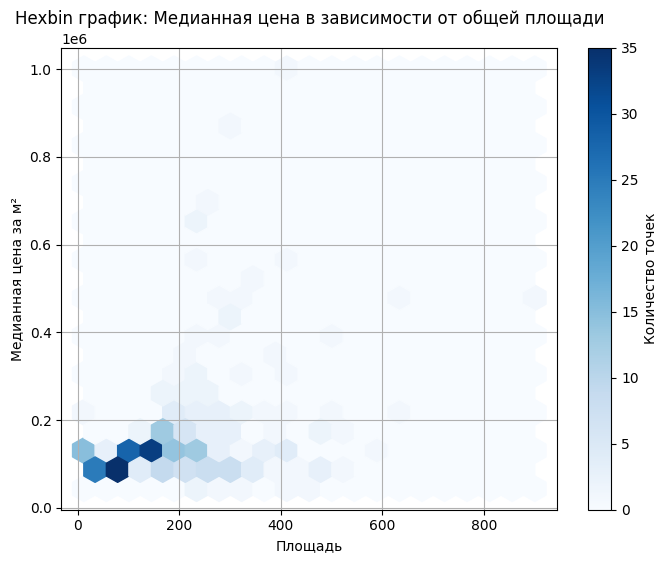

In [172]:
# ЦЗависимость цены от площади объекта в Санкт-Петербурге
# Фильтрация данных для Санкт-Петербурга и группировка
data_S_P_tolal_area_price = data[data['locality_name'] == 'г. Санкт-Петербург'].groupby('total_area')['m_2_price'].agg('median')

# Печать медианных значений
print(data_S_P_tolal_area_price)

# Построение графика hexbin
plt.figure(figsize=(8, 6))
plt.hexbin(data_S_P_tolal_area_price.index, data_S_P_tolal_area_price.values, gridsize=20, cmap='Blues')
plt.colorbar(label='Количество точек')
plt.title('Hexbin график: Медианная цена в зависимости от общей площади')
plt.xlabel('Площадь')
plt.ylabel('Медианная цена за м²')
plt.grid(True)
plt.show()

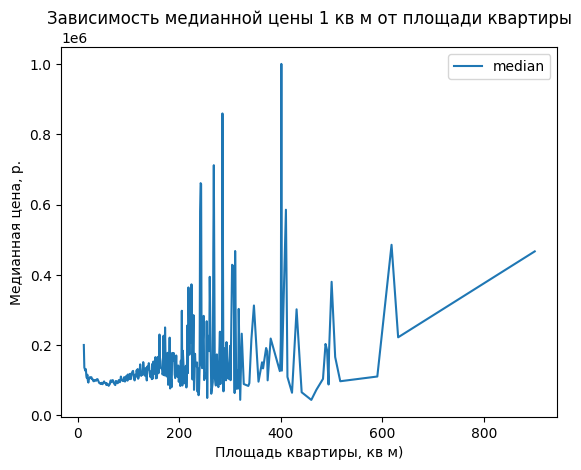

In [173]:
# Зависимость медианной цены  м от площади квартиры
data.groupby('total_area')['m_2_price'].agg(['median']).plot()
plt.title('Зависимость медианной цены 1 кв м от площади квартиры')
plt.xlabel('Площадь квартиры, кв м)')
plt.ylabel('Медианная цена, р.')
plt.show()

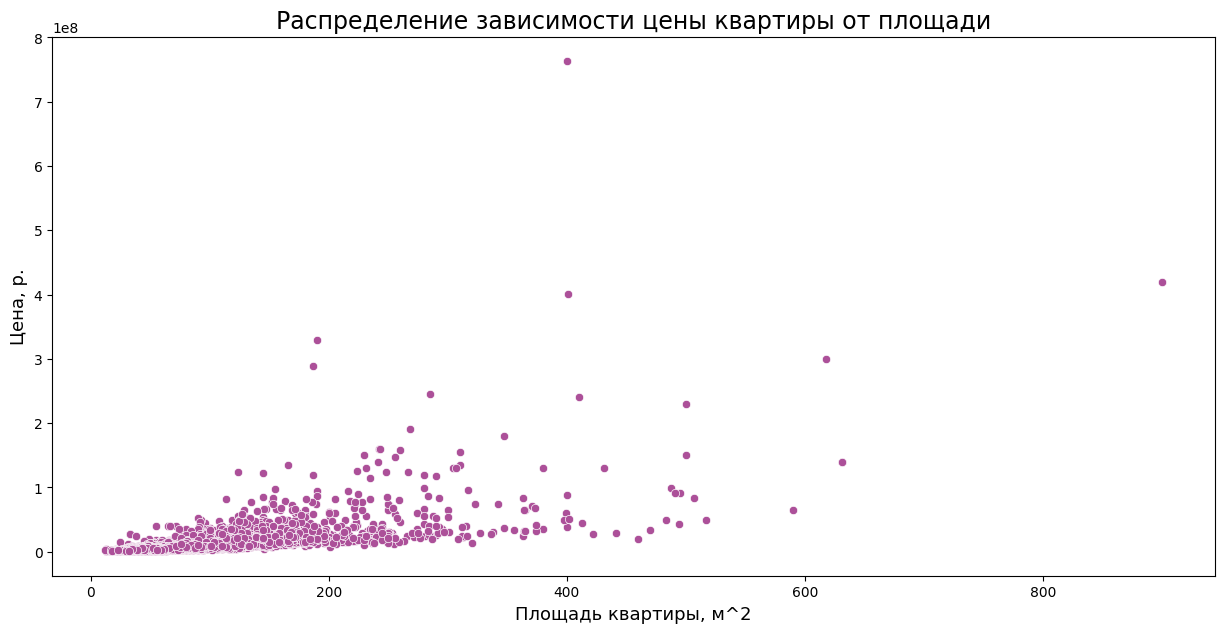

In [174]:
# Зависимость медианной цены 1 кв м от площади квартиры
plt.figure(figsize=(15, 7))

sns.scatterplot(data=data,  x='total_area', y='last_price', color='#AC5099')

plt.title('Распределение зависимости цены квартиры от площади', size=17)
plt.xlabel('Площадь квартиры, м^2', size=13)
plt.ylabel('Цена, р.', size=13)

plt.show()

Чем меньше площадь, тем больше цена квартиры.

In [175]:
# Цена от площади в Санкт-Петербурге
# Фильтрация данных для Санкт-Петербурга и группировка
data_S_P_tolal_area_price = data[data['locality_name'] == 'г. Санкт-Петербург'].groupby('total_area')['last_price'].agg('median')

# Печать медианных значений
print(data_S_P_tolal_area_price)

total_area
12.0       2400000.0
13.0       1768000.0
15.0       2000000.0
16.0       2100000.0
17.0       2050000.0
            ...     
517.0     50000000.0
590.0     65000000.0
618.0    300000000.0
631.0    140000000.0
900.0    420000000.0
Name: last_price, Length: 308, dtype: float64


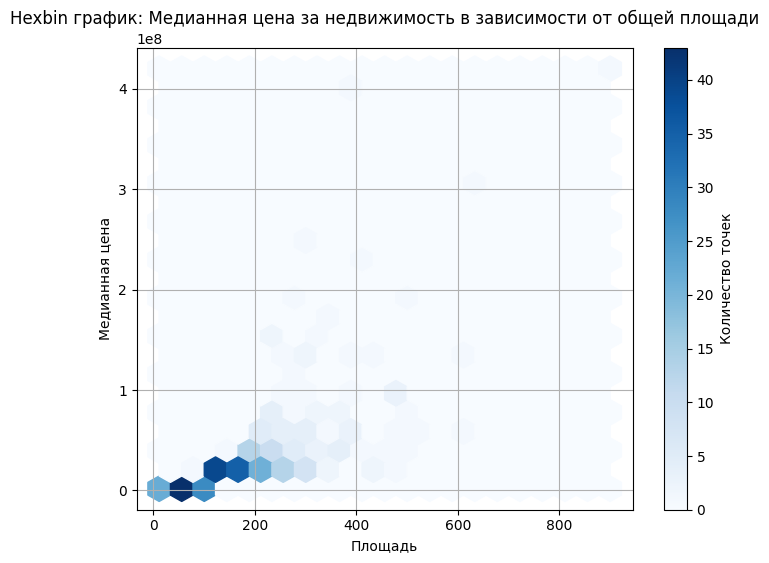

In [176]:
# Построение графика hexbin
plt.figure(figsize=(8, 6))
plt.hexbin(data_S_P_tolal_area_price.index, data_S_P_tolal_area_price.values, gridsize=20, cmap='Blues')
plt.colorbar(label='Количество точек')
plt.title('Hexbin график: Медианная цена за недвижимость в зависимости от общей площади')
plt.xlabel('Площадь')
plt.ylabel('Медианная цена')
plt.grid(True)
plt.show()

Самая высокая цена у квартир c бОльшей площадью. Чаще всего продаются квартиры 50-100 кв м.

### Напишите общий вывод

# Общий вывод


 **Задачи**:
- провести предобработку данных: выявить и, по возможности, заполнить пропуски, устранить дубликаты, найти аномалии/ошибки и исправить их или  (при невозможности исправления) удалить строки с ними;
- дополнить датафрэйм новыми столбцами с характеристиками недвижимости для удобства дальнейшего анализа;
- провести анализ влияния параметров на рыночную стоимость недвижимости

**выполнены**.



**Влияние параметров на стоимость квартир**
        
Чем больше общая площадь, тем больше стоимость недвижимости.

Чем больше жилая площадь, тем больше стоимость недвижимости.

Чем больше площадь кухни, тем больше стоимость недвижимости.

Чем больше количество комнат, тем больше стоимость недвижимости.

Самый дешевый - 1й этаж, дороже - последний этаж, самые дорогие - остальные этажи.

Чем позже размещено объявление о продаже недвижимости, тем дороже цена квартиры - всилу общего повышения цен со временем.

При политических и/или экономических резких изменениях резко увеличивается и стоимость квартир.

Стоимость квартир зависит и от месяца размещения - сезонности. Высокий сезон - новогодний (11,12,01 месяцы), весенний - апрель, летний - июль, август. Когда люди освобождаются полностью или частично от бытовых дел (дачи, отпуска, сдача учебных экзаменов и тд) и от рабочих дел - когда люди сдали рабочие проекты/отчеты перед госорганами и тд.

Стоимость недвижимости зависит от ее типа. Цена квартир меньше, но сравнима с ценой аппартаментов. Квартир продается на рынке больше.

Чем ближе к центру города, тем стоимость недвижимости.

Чем ближе и чем больше парков рядом, тем больше стоимость недвижимости.

Чем ближе водоемы, тем больше стоимость недвижимости.


**Населенные пункты с самой высокой и низкой стоимостью квадратного метра** из всего датафрэйма.

В г. Санкт-Петербург - самая высокая стоимость 1 кв м (максимальная медианная) составляет 103 254 р.

В п. Плодовое - самая низкая стоимость 1 кв м (минимальная медианная) составляет 31 838 р.


**Длительность продажи**

Обычно продажа недвижимости занимает 95 дней.

Продажи длительностью 44 дня и меньше можно считать быстрыми, а длительностью от 232 дней - необычно долгими.


**Рыночная стоимость объектов недвижимости определяется** совокупностью вышеприведенных параментов и выводится из медианной цены объектов со схожими характеристиками.
**Аномалии и признаки мошеннической деятельности** определены и устранены или исправлены.

**Цель** проекта:

- определить параметры, влияющие на рыночную стоимость объектов недвижимости.

- определить аномалии и признаки мошеннической деятельности для построения автоматизированной системы их отслеживания
**выполнена**

**Комментарии**

- Оценка стоимости квартир велась по медиане, чтобы не учитывать выбросы цен, и учитывать усредненное медианное наиболее часто встречающееся значение.

- Для выявления параметров, влияющих на стоимость жилой недвижимости не достаточно данных. Люди оценивают стоимость квартиры также по наличию рядом объектов инфраструктуры. К ним относятся - сады, школы, университеты, транспорт и его виды, скорость добирания до центра, пробочную обстановку, экологию, наличие и отсутствие ремонта, параментры ремонта - дизайнерский, старый, без ремонта и тд, тип здания, огороженность, наличие авто, вело и тд парковок, детских площадок.

- в задании не было, но я провела также исследование зависимости длительности продаж от нескольикх параментров. Т.к. считаю, длительность и цену надо рассматривать в совокупности. Поставил большую цену - ждешь долго, упускаешь время, возможность реализации полученного дохода на желаемые вещи. Поставил низкую - продал быстро, но денег не хватит на желаемые вещи.